In [95]:
import os
import time
import numpy as np
import seaborn as sns
from numpy.polynomial.legendre import leggauss
from matplotlib import pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
folder = "./hybridMixedFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho3_"

directory ./hybridMixedFEM already created


In [4]:
def exact_p(x):
    return np.cos(np.pi * x)

def exact_u(x):
    return np.pi * np.sin(np.pi * x)

def exact_f(x):
    return (np.pi ** 2) * np.cos(np.pi * x)

def exact_g(x):
    return exact_p(x)

def exact_lambda(x):
    return exact_p(x)

In [5]:
def create_mesh(l, n_elem):
    nodes = np.linspace(0, l, n_elem + 1)
    elements = np.array([[i, i + 1] for i in range(n_elem)])
    return nodes, elements

In [6]:
def lagrange_shape(k, xi):
    xi_nodes = np.linspace(-1.0, 1.0, k + 1)

    N = np.ones(k + 1)
    dN_dxi = np.zeros(k + 1)

    for i in range(k + 1):
        for j in range(k + 1):
            if i != j:
                N[i] *= (xi - xi_nodes[j]) / (xi_nodes[i] - xi_nodes[j])

    for i in range(k + 1):
        soma = 0.0

        for m in range(k + 1):
            if m != i:
                termo = 1.0 / (xi_nodes[i] - xi_nodes[m])

                for j in range(k + 1):
                    if j != i and j != m:
                        termo *= (xi - xi_nodes[j]) / (xi_nodes[i] - xi_nodes[j])

                soma += termo

        dN_dxi[i] = soma

    return N, dN_dxi

### Teste das funções exatas

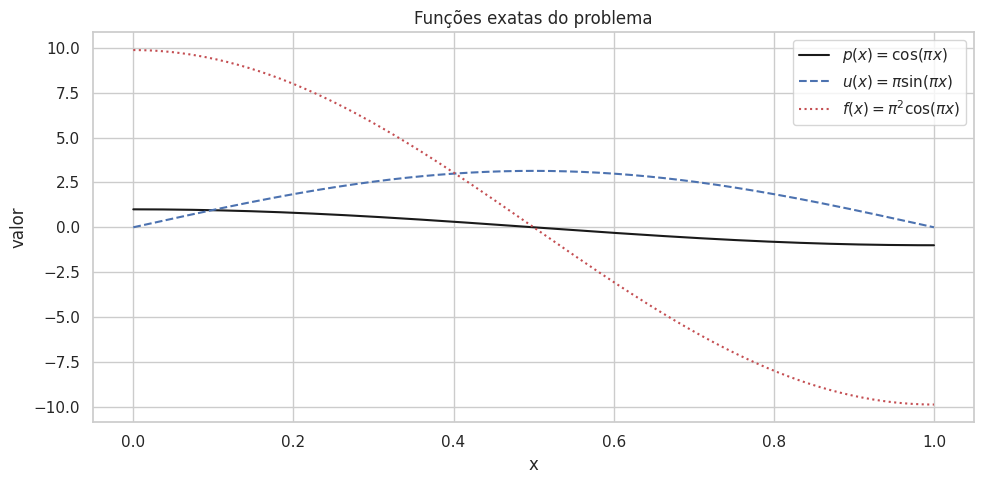

In [7]:
x_exact = np.linspace(0, 1, 300)

plt.figure(figsize=(10, 5))

plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'$p(x) = \cos(\pi x)$')
plt.plot(x_exact, exact_u(x_exact), 'b--', label=r'$u(x) = \pi\sin(\pi x)$')
plt.plot(x_exact, exact_f(x_exact), 'r:', label=r'$f(x) = \pi^2\cos(\pi x)$')

plt.title("Funções exatas do problema")
plt.xlabel("x")
plt.ylabel("valor")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "funcoes_exatas.pdf")
plt.show()

In [8]:
def local_matrices_dual_known_lambda(x1, x2, k, beta, delta1=0.0, delta2=0.0):
    h = x2 - x1
    J = h / 2.0

    n_loc_nodes = k + 1
    n_local_unknowns = 2 * n_loc_nodes

    A_loc = np.zeros((n_local_unknowns, n_local_unknowns))
    B_loc = np.zeros((n_local_unknowns, 2))
    F_loc = np.zeros(n_local_unknowns)

    gauss_pts, weights = leggauss(k + 3)

    x_coords = np.linspace(x1, x2, n_loc_nodes)

    for gp, w in zip(gauss_pts, weights):
        N, dN_dxi = lagrange_shape(k, gp)
        dN_dx = dN_dxi / J

        x_gp = np.dot(N, x_coords)
        f_val = exact_f(x_gp)

        for j in range(n_loc_nodes):
            row_v = j
            row_q = n_loc_nodes + j

            # Termo do lado direito:
            # F([v,q]) = - int_K f q dx + delta2 int_K f v' dx

            F_loc[row_v] += delta2 * f_val * dN_dx[j] * w * J
            F_loc[row_q] += -f_val * N[j] * w * J

            for i in range(n_loc_nodes):
                col_u = i
                col_p = n_loc_nodes + i

                # Linha associada ao teste v
                #
                # int_K u v dx
                # - int_K p v' dx
                # + delta1 int_K (u + p') v dx
                # + delta2 int_K u' v' dx

                A_loc[row_v, col_u] += N[i] * N[j] * w * J
                A_loc[row_v, col_p] += -N[i] * dN_dx[j] * w * J

                A_loc[row_v, col_u] += delta1 * N[i] * N[j] * w * J
                A_loc[row_v, col_p] += delta1 * dN_dx[i] * N[j] * w * J

                A_loc[row_v, col_u] += delta2 * dN_dx[i] * dN_dx[j] * w * J

                # Linha associada ao teste q
                #
                # - int_K q u' dx
                # + delta1 int_K (u + p') q' dx

                A_loc[row_q, col_u] += -dN_dx[i] * N[j] * w * J

                A_loc[row_q, col_u] += delta1 * N[i] * dN_dx[j] * w * J
                A_loc[row_q, col_p] += delta1 * dN_dx[i] * dN_dx[j] * w * J

    # Termos de fronteira:
    # [a]_{x1}^{x2} = a(x2) - a(x1)

    boundary_data = [
        {"xi": -1.0, "lambda_index": 0, "sign": -1.0},
        {"xi":  1.0, "lambda_index": 1, "sign":  1.0}
    ]

    for bd in boundary_data:
        xi_b = bd["xi"]
        lambda_index = bd["lambda_index"]
        sign = bd["sign"]

        N_b, _ = lagrange_shape(k, xi_b)

        for j in range(n_loc_nodes):
            row_v = j
            row_q = n_loc_nodes + j

            # b(lambda, [v,q]) = lambda v| - beta lambda q|

            B_loc[row_v, lambda_index] += sign * N_b[j]
            B_loc[row_q, lambda_index] += -beta * sign * N_b[j]

            for i in range(n_loc_nodes):
                col_p = n_loc_nodes + i

                # beta p q|

                A_loc[row_q, col_p] += beta * sign * N_b[i] * N_b[j]

    return A_loc, B_loc, F_loc

In [9]:
def solve_dual_known_lambda(l, n_elem, k, beta0, delta1=0.0, delta2=0.0):
    nodes, elements = create_mesh(l, n_elem)

    u_app = np.zeros((n_elem, k + 1))
    p_app = np.zeros((n_elem, k + 1))

    cond_numbers = []

    h = l / n_elem
    beta = beta0 / h

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        A_loc, B_loc, F_loc = local_matrices_dual_known_lambda(
            x1,
            x2,
            k,
            beta,
            delta1,
            delta2
        )

        lambda_loc = np.array([
            exact_lambda(x1),
            exact_lambda(x2)
        ])

        rhs_loc = F_loc - B_loc @ lambda_loc

        cond_numbers.append(np.linalg.cond(A_loc))

        try:
            U_loc = np.linalg.solve(A_loc, rhs_loc)
        except np.linalg.LinAlgError:
            print(
                f"Matriz local singular no elemento {elem_id}. "
                f"Usando mínimos quadrados."
            )
            U_loc = np.linalg.lstsq(A_loc, rhs_loc, rcond=None)[0]

        u_app[elem_id, :] = U_loc[:k + 1]
        p_app[elem_id, :] = U_loc[k + 1:]

    return nodes, elements, u_app, p_app, cond_numbers, beta

In [10]:
def compute_L2_error_discontinuous_variable(nodes, elements, var_app, k, exact_function):
    gauss_pts, weights = leggauss(k + 4)

    error_sq = 0.0

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        x_coords = np.linspace(x1, x2, k + 1)
        var_loc = var_app[elem_id, :]

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N, _ = lagrange_shape(k, gp)

            x_gp = np.dot(N, x_coords)
            var_h_gp = np.dot(N, var_loc)
            var_ex_gp = exact_function(x_gp)

            error_sq += (var_ex_gp - var_h_gp) ** 2 * w * J

    return np.sqrt(error_sq)

In [11]:
def build_discontinuous_plot_data_mixed(nodes, elements, u_app, p_app, k, n_points_per_element=30):
    x_plot = []
    u_plot = []
    p_plot = []

    xi_plot = np.linspace(-1.0, 1.0, n_points_per_element)

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        x_coords = np.linspace(x1, x2, k + 1)

        u_loc = u_app[elem_id, :]
        p_loc = p_app[elem_id, :]

        for xi in xi_plot:
            N, _ = lagrange_shape(k, xi)

            x_val = np.dot(N, x_coords)
            u_val = np.dot(N, u_loc)
            p_val = np.dot(N, p_loc)

            x_plot.append(x_val)
            u_plot.append(u_val)
            p_plot.append(p_val)

        x_plot.append(np.nan)
        u_plot.append(np.nan)
        p_plot.append(np.nan)

    return np.array(x_plot), np.array(u_plot), np.array(p_plot)

In [29]:
def convergence_table_known_lambda(
    n_elem_list,
    k,
    beta0,
    delta1=0.0,
    delta2=0.0,
    title="",
    l=1.0
):
    results = []

    previous_h = None
    previous_err_u = None
    previous_err_p = None

    print(title)
    print("-" * 115)
    print(
        f"{'Nelem':<8} | {'k':<3} | {'h':<12} | {'beta':<12} | "
        f"{'Erro u':<12} | {'taxa u':<10} | {'Erro p':<12} | {'taxa p':<10} | {'tempo (s)':<10}"
    )
    print("-" * 115)

    for n_elem in n_elem_list:
        start = time.time()

        nodes, elements, u_app, p_app, cond_numbers, beta = solve_dual_known_lambda(
            l,
            n_elem,
            k,
            beta0,
            delta1=delta1,
            delta2=delta2
        )

        err_u = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            u_app,
            k,
            exact_u
        )

        err_p = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            p_app,
            k,
            exact_p
        )

        elapsed_time = time.time() - start

        h = l / n_elem

        if previous_h is None:
            rate_u = np.nan
            rate_p = np.nan
        else:
            rate_u = np.log(previous_err_u / err_u) / np.log(previous_h / h)
            rate_p = np.log(previous_err_p / err_p) / np.log(previous_h / h)

        results.append({
            "Nelem": n_elem,
            "k": k,
            "h": h,
            "beta": beta,
            "err_u": err_u,
            "rate_u": rate_u,
            "err_p": err_p,
            "rate_p": rate_p,
            "time": elapsed_time,
            "cond_max": max(cond_numbers)
        })

        if np.isnan(rate_u):
            rate_u_str = "-"
            rate_p_str = "-"
        else:
            rate_u_str = f"{rate_u:.3f}"
            rate_p_str = f"{rate_p:.3f}"

        print(
            f"{n_elem:<8} | {k:<3} | {h:<12.4e} | {beta:<12.4e} | "
            f"{err_u:<12.4e} | {rate_u_str:<10} | "
            f"{err_p:<12.4e} | {rate_p_str:<10} | {elapsed_time:<10.4f}"
        )

        previous_h = h
        previous_err_u = err_u
        previous_err_p = err_p

    print("-" * 115)

    return results

In [39]:
def plot_single_error_loglog(
    results,
    variable="u",
    title="Erro L2",
    x_axis="h",
    save_name=None,
    invert_h_axis=True
):
    if x_axis not in ["h", "nelem"]:
        raise ValueError("x_axis deve ser 'h' ou 'nelem'.")

    if variable not in ["u", "p"]:
        raise ValueError("variable deve ser 'u' ou 'p'.")

    nelem = np.array([row["Nelem"] for row in results])
    h = np.array([row["h"] for row in results])

    if variable == "u":
        error = np.array([row["err_u"] for row in results])
        ylabel = r"$\|u-u_h\|_{L^2}$"
        label = r"Erro de $u$"
    else:
        error = np.array([row["err_p"] for row in results])
        ylabel = r"$\|p-p_h\|_{L^2}$"
        label = r"Erro de $p$"

    if x_axis == "h":
        x = h
        xlabel = r"$h$"
    else:
        x = nelem
        xlabel = r"$N_{elem}$"

    plt.figure(figsize=(9, 6))

    plt.loglog(x, error, "o-", label=label)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, which="both")

    if x_axis == "h" and invert_h_axis:
        plt.gca().invert_xaxis()

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(folder + save_name)

    plt.show()

In [36]:
L = 1.0
n_elem = 64
k = 1
beta0 = 10.0

nodes, elements, u_app, p_app, cond_numbers, beta = solve_dual_known_lambda(
    L,
    n_elem,
    k,
    beta0,
    delta1=0.0,
    delta2=0.0
)

err_u = compute_L2_error_discontinuous_variable(
    nodes,
    elements,
    u_app,
    k,
    exact_u
)

err_p = compute_L2_error_discontinuous_variable(
    nodes,
    elements,
    p_app,
    k,
    exact_p
)



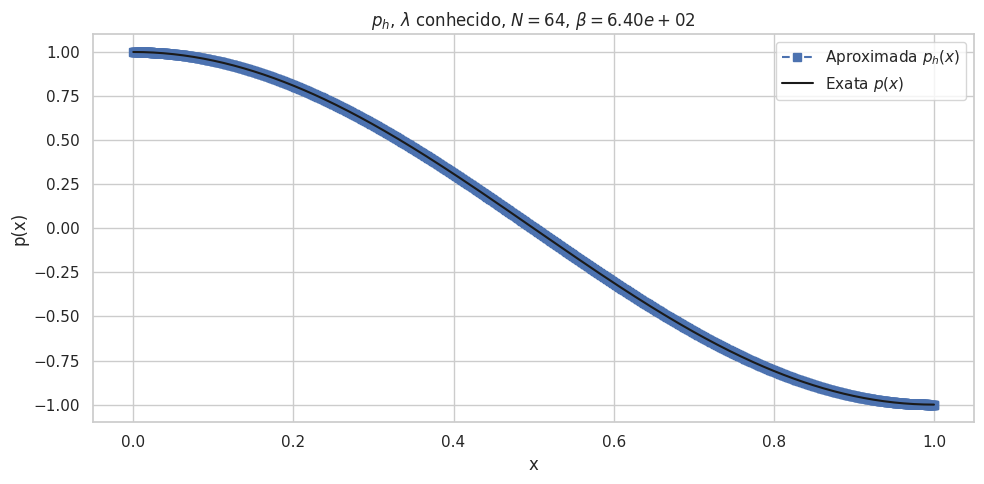

In [37]:
x_exact = np.linspace(0, L, 400)

x_disc, u_disc, p_disc = build_discontinuous_plot_data_mixed(
    nodes,
    elements,
    u_app,
    p_app,
    k
)

plt.figure(figsize=(10, 5))

plt.plot(x_disc, p_disc, 'bs--', label=r'Aproximada $p_h(x)$')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'$p_h$, $\lambda$ conhecido, $N={n_elem}$, $\beta={beta:.2e}$')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_c_p_lambda_conhecido.pdf")
plt.show()

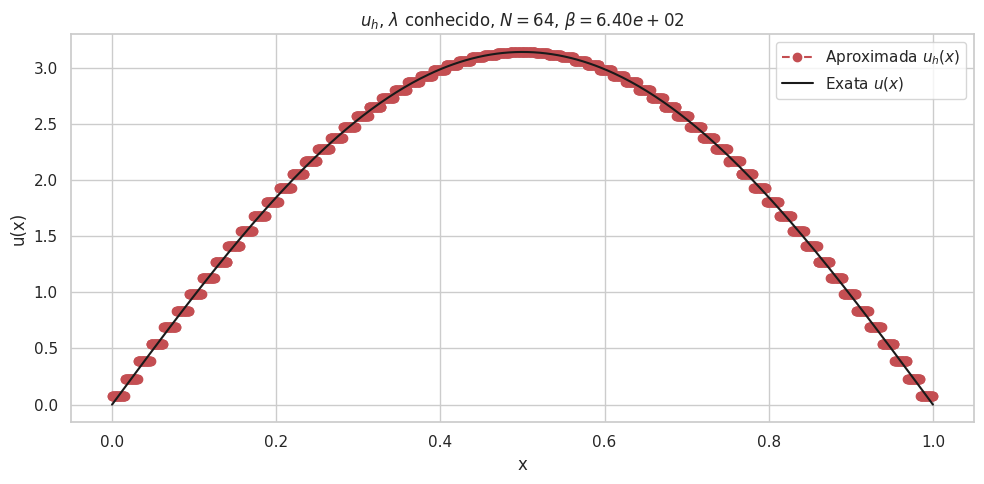

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(x_disc, u_disc, 'ro--', label=r'Aproximada $u_h(x)$')
plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')

plt.title(rf'$u_h$, $\lambda$ conhecido, $N={n_elem}$, $\beta={beta:.2e}$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_c_u_lambda_conhecido.pdf")
plt.show()

In [21]:
delta1 = -0.5
delta2 = 0.0
beta0 = 0.0

In [35]:
L = 1.0
n_elem = 64
k = 1

beta0 = 0.0
delta1 = -0.5
delta2 = 0.0

nodes_d, elements_d, u_app_d, p_app_d, cond_numbers_d, beta_d = solve_dual_known_lambda(
    L,
    n_elem,
    k,
    beta0,
    delta1=delta1,
    delta2=delta2
)

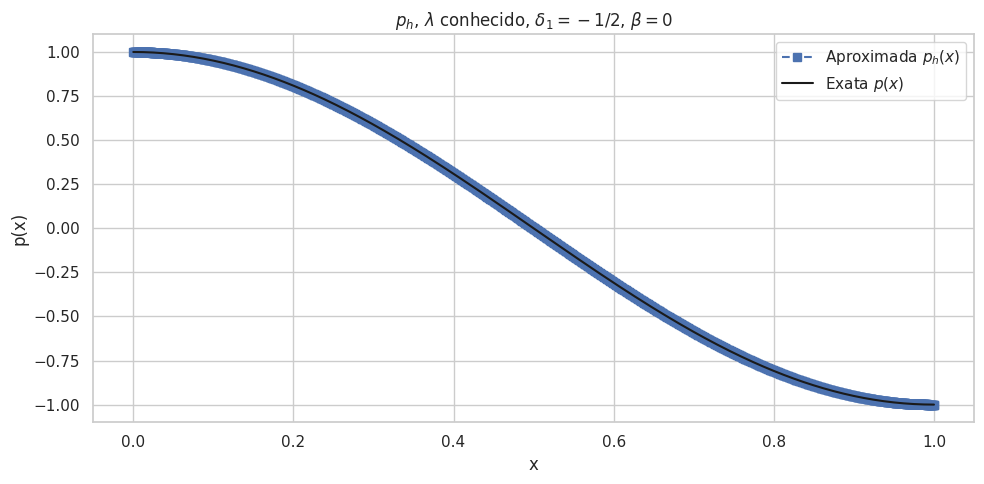

In [26]:
x_exact = np.linspace(0, L, 400)

x_disc_d, u_disc_d, p_disc_d = build_discontinuous_plot_data_mixed(
    nodes_d,
    elements_d,
    u_app_d,
    p_app_d,
    k
)

plt.figure(figsize=(10, 5))

plt.plot(x_disc_d, p_disc_d, 'bs--', label=r'Aproximada $p_h(x)$')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'$p_h$, $\lambda$ conhecido, $\delta_1=-1/2$, $\beta=0$')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_d_p_lambda_conhecido_delta1.pdf")
plt.show()

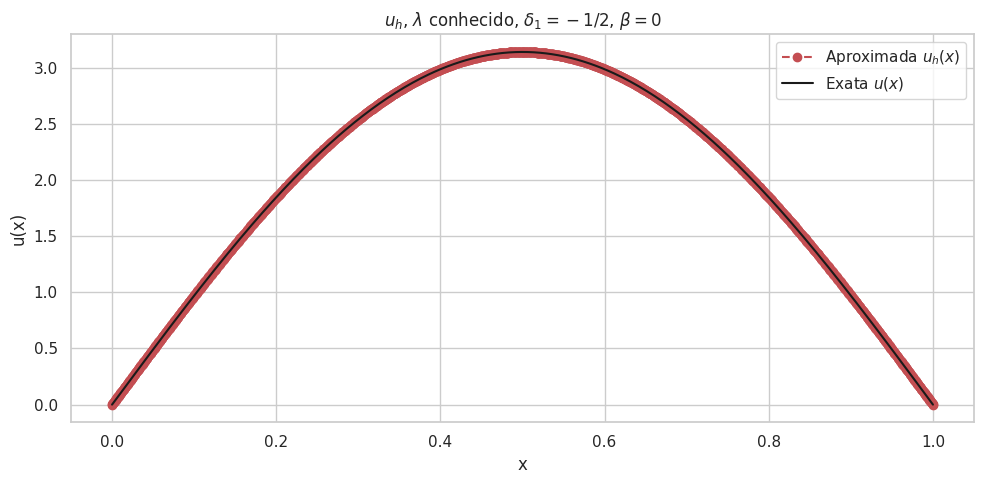

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(x_disc_d, u_disc_d, 'ro--', label=r'Aproximada $u_h(x)$')
plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')

plt.title(rf'$u_h$, $\lambda$ conhecido, $\delta_1=-1/2$, $\beta=0$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_d_u_lambda_conhecido_delta1.pdf")
plt.show()

In [34]:
def plot_error_loglog(
    results,
    title="Erro L2 em função do refinamento",
    x_axis="h",
    save_name=None,
    invert_h_axis=True
):
    if x_axis not in ["h", "nelem"]:
        raise ValueError("x_axis deve ser 'h' ou 'nelem'.")

    nelem = np.array([row["Nelem"] for row in results])
    h = np.array([row["h"] for row in results])
    err_u = np.array([row["err_u"] for row in results])
    err_p = np.array([row["err_p"] for row in results])

    if x_axis == "h":
        x = h
        xlabel = r"$h$"
    else:
        x = nelem
        xlabel = r"$N_{elem}$"

    plt.figure(figsize=(9, 6))

    plt.loglog(x, err_u, "o-", label=r"$\|u - u_h\|_{L^2}$")
    plt.loglog(x, err_p, "s--", label=r"$\|p - p_h\|_{L^2}$")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(r"Erro $L^2$")
    plt.legend()
    plt.grid(True, which="both")

    if x_axis == "h" and invert_h_axis:
        plt.gca().invert_xaxis()

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(folder + save_name)

    plt.show()

In [30]:
n_elem_list = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8000]

results_c = convergence_table_known_lambda(
    n_elem_list=n_elem_list,
    k=1,
    beta0=10.0,
    delta1=0.0,
    delta2=0.0,
    title="TABELA ITEM (c) - LAMBDA CONHECIDO, BETA != 0"
)

TABELA ITEM (c) - LAMBDA CONHECIDO, BETA != 0
-------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | beta         | Erro u       | taxa u     | Erro p       | taxa p     | tempo (s) 
-------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 1.6000e+02   | 1.2586e-01   | -          | 2.6083e-03   | -          | 0.0132    
32       | 1   | 3.1250e-02   | 3.2000e+02   | 6.2950e-02   | 1.000      | 6.5240e-04   | 1.999      | 0.0238    
64       | 1   | 1.5625e-02   | 6.4000e+02   | 3.1478e-02   | 1.000      | 1.6312e-04   | 2.000      | 0.0470    
128      | 1   | 7.8125e-03   | 1.2800e+03   | 1.5739e-02   | 1.000      | 4.0782e-05   | 2.000      | 0.0934    
256      | 1   | 3.9062e-03   | 2.5600e+03   | 7.8696e-03   | 1.000      | 1.0196e-05   | 2.000      | 0.1871    
512      | 1   | 1.9531e-03   | 5.1200

In [31]:
results_d = convergence_table_known_lambda(
    n_elem_list=n_elem_list,
    k=1,
    beta0=0.0,
    delta1=-0.5,
    delta2=0.0,
    title="TABELA ITEM (d) - LAMBDA CONHECIDO, DELTA1 = -1/2, BETA = 0"
)

TABELA ITEM (d) - LAMBDA CONHECIDO, DELTA1 = -1/2, BETA = 0
-------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | beta         | Erro u       | taxa u     | Erro p       | taxa p     | tempo (s) 
-------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 0.0000e+00   | 7.8116e-03   | -          | 1.5268e-03   | -          | 0.0128    
32       | 1   | 3.1250e-02   | 0.0000e+00   | 1.9541e-03   | 1.999      | 3.8116e-04   | 2.002      | 0.0237    
64       | 1   | 1.5625e-02   | 0.0000e+00   | 4.8861e-04   | 2.000      | 9.5258e-05   | 2.001      | 0.0445    
128      | 1   | 7.8125e-03   | 0.0000e+00   | 1.2216e-04   | 2.000      | 2.3812e-05   | 2.000      | 0.0647    
256      | 1   | 3.9062e-03   | 0.0000e+00   | 3.0540e-05   | 2.000      | 5.9530e-06   | 2.000      | 0.1290    
512      | 1   | 1.9531e

In [32]:
def save_convergence_table_txt(results, filename):
    with open(filename, "w") as file:
        file.write(
            f"{'Nelem':<8} | {'k':<3} | {'h':<12} | {'beta':<12} | "
            f"{'Erro u':<12} | {'taxa u':<10} | {'Erro p':<12} | "
            f"{'taxa p':<10} | {'tempo (s)':<10} | {'cond max':<12}\n"
        )
        file.write("-" * 130 + "\n")

        for row in results:
            if np.isnan(row["rate_u"]):
                rate_u_str = "-"
                rate_p_str = "-"
            else:
                rate_u_str = f"{row['rate_u']:.4f}"
                rate_p_str = f"{row['rate_p']:.4f}"

            file.write(
                f"{row['Nelem']:<8} | {row['k']:<3} | {row['h']:<12.4e} | "
                f"{row['beta']:<12.4e} | {row['err_u']:<12.4e} | "
                f"{rate_u_str:<10} | {row['err_p']:<12.4e} | "
                f"{rate_p_str:<10} | {row['time']:<10.4f} | "
                f"{row['cond_max']:<12.4e}\n"
            )

In [33]:
save_convergence_table_txt(
    results_c,
    folder + "tabela_item_c_lambda_conhecido.txt"
)

save_convergence_table_txt(
    results_d,
    folder + "tabela_item_d_lambda_conhecido_delta1.txt"
)

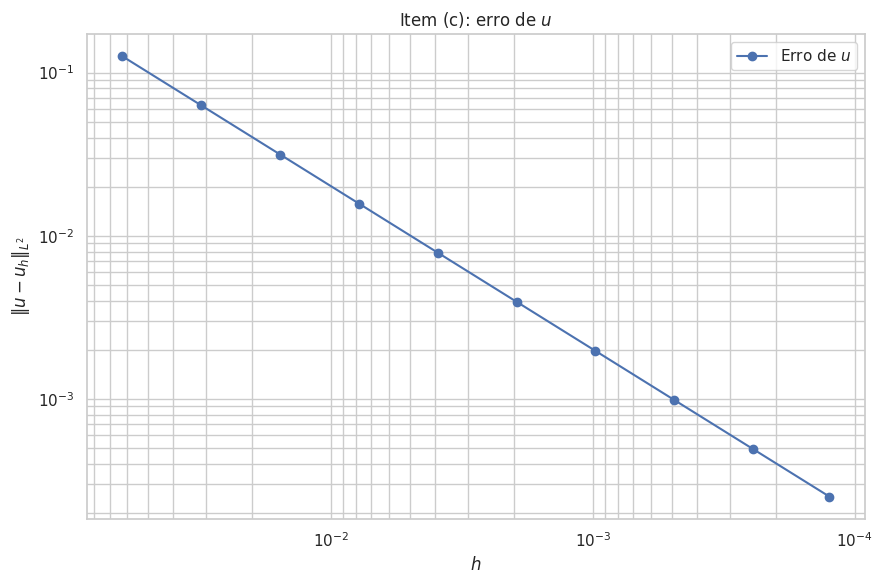

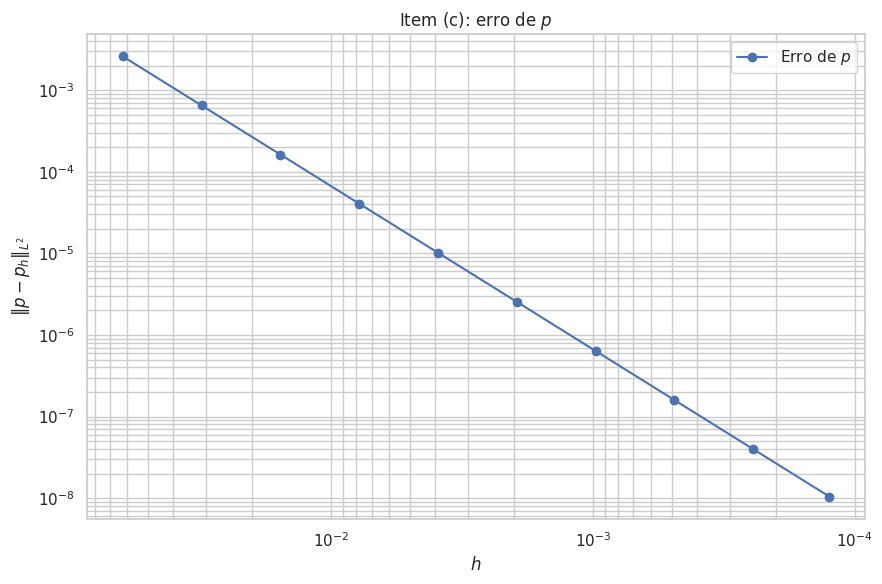

In [40]:
plot_single_error_loglog(
    results_c,
    variable="u",
    title=r"Item (c): erro de $u$",
    x_axis="h",
    save_name="item_c_erro_u_loglog_h.pdf"
)

plot_single_error_loglog(
    results_c,
    variable="p",
    title=r"Item (c): erro de $p$",
    x_axis="h",
    save_name="item_c_erro_p_loglog_h.pdf"
)

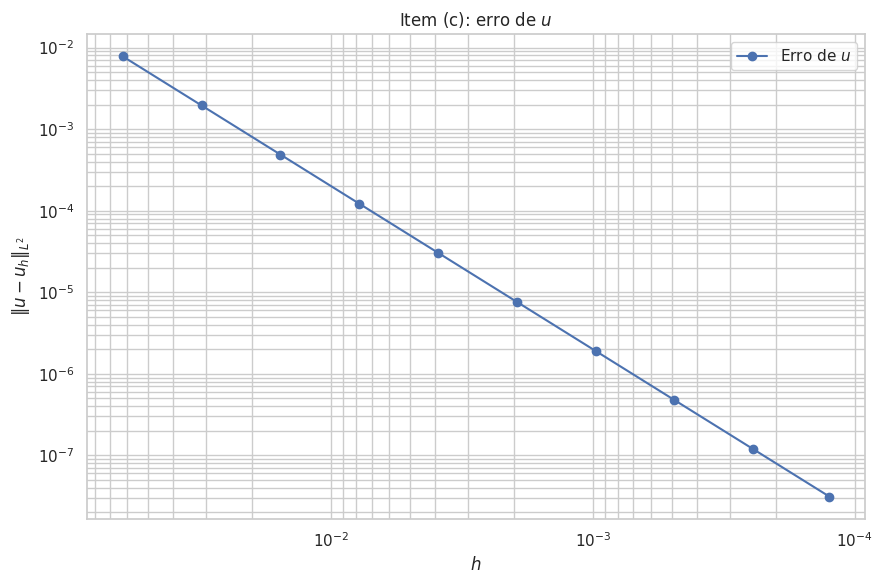

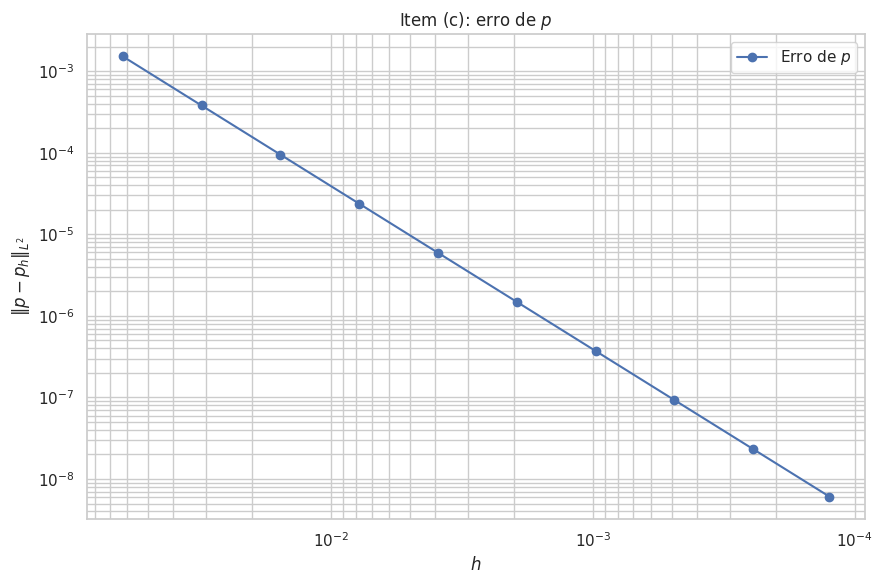

In [41]:
plot_single_error_loglog(
    results_d,
    variable="u",
    title=r"Item (c): erro de $u$",
    x_axis="h",
    save_name="item_c_erro_u_loglog_h.pdf"
)

plot_single_error_loglog(
    results_d,
    variable="p",
    title=r"Item (c): erro de $p$",
    x_axis="h",
    save_name="item_c_erro_p_loglog_h.pdf"
)

In [42]:
def local_matrices_dual_hybrid(x1, x2, k, beta, delta1=0.0, delta2=0.0):
    A_loc, B_loc, F_loc = local_matrices_dual_known_lambda(
        x1,
        x2,
        k,
        beta,
        delta1,
        delta2
    )

    C_loc = np.zeros((2, 2))

    # c(lambda, mu) = beta * lambda * mu |_{x1}^{x2}
    #
    # lado esquerdo: sinal negativo
    # lado direito: sinal positivo

    C_loc[0, 0] += -beta
    C_loc[1, 1] += beta

    return A_loc, B_loc, C_loc, F_loc

In [43]:
def assemble_lambda_system_dual_hybrid(
    l,
    n_elem,
    k,
    beta0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h"
):
    nodes, elements = create_mesh(l, n_elem)

    n_lambda = n_elem + 1

    K_global = np.zeros((n_lambda, n_lambda))
    F_global = np.zeros(n_lambda)

    local_data = []

    h = l / n_elem

    if beta_scale == "k2_over_h":
        beta = beta0 * (k ** 2) / h
    elif beta_scale == "one_over_h":
        beta = beta0 / h
    elif beta_scale == "constant":
        beta = beta0
    else:
        raise ValueError("beta_scale deve ser 'k2_over_h', 'one_over_h' ou 'constant'.")

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        A_loc, B_loc, C_loc, F_loc = local_matrices_dual_hybrid(
            x1,
            x2,
            k,
            beta,
            delta1,
            delta2
        )

        A_inv_B = np.linalg.solve(A_loc, B_loc)
        A_inv_F = np.linalg.solve(A_loc, F_loc)

        K_loc = B_loc.T @ A_inv_B - C_loc
        F_lambda_loc = B_loc.T @ A_inv_F

        lambda_ids = [n1, n2]

        for i_local, i_global in enumerate(lambda_ids):
            F_global[i_global] += F_lambda_loc[i_local]

            for j_local, j_global in enumerate(lambda_ids):
                K_global[i_global, j_global] += K_loc[i_local, j_local]

        local_data.append({
            "A": A_loc,
            "B": B_loc,
            "F": F_loc,
            "lambda_ids": lambda_ids
        })

    return nodes, elements, K_global, F_global, local_data, beta

In [44]:
def apply_dirichlet_bc_lambda(K_global, F_global, nodes):
    K_bc = K_global.copy()
    F_bc = F_global.copy()

    bc_nodes = [0, len(nodes) - 1]
    bc_values = [
        exact_g(nodes[0]),
        exact_g(nodes[-1])
    ]

    K_original = K_global.copy()

    for node_id, value in zip(bc_nodes, bc_values):
        F_bc -= K_original[:, node_id] * value

    for node_id, value in zip(bc_nodes, bc_values):
        K_bc[node_id, :] = 0.0
        K_bc[:, node_id] = 0.0
        K_bc[node_id, node_id] = 1.0
        F_bc[node_id] = value

    return K_bc, F_bc

In [45]:
def solve_dual_hybrid(
    l,
    n_elem,
    k,
    beta0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h"
):
    nodes, elements, K_global, F_global, local_data, beta = assemble_lambda_system_dual_hybrid(
        l,
        n_elem,
        k,
        beta0,
        delta1,
        delta2,
        beta_scale
    )

    K_bc, F_bc = apply_dirichlet_bc_lambda(
        K_global,
        F_global,
        nodes
    )

    lambda_app = np.linalg.solve(K_bc, F_bc)

    u_app = np.zeros((n_elem, k + 1))
    p_app = np.zeros((n_elem, k + 1))

    cond_local = []

    for elem_id, data in enumerate(local_data):
        A_loc = data["A"]
        B_loc = data["B"]
        F_loc = data["F"]

        lambda_ids = data["lambda_ids"]

        lambda_loc = np.array([
            lambda_app[lambda_ids[0]],
            lambda_app[lambda_ids[1]]
        ])

        rhs_loc = F_loc - B_loc @ lambda_loc

        cond_local.append(np.linalg.cond(A_loc))

        U_loc = np.linalg.solve(A_loc, rhs_loc)

        u_app[elem_id, :] = U_loc[:k + 1]
        p_app[elem_id, :] = U_loc[k + 1:]

    return nodes, elements, lambda_app, u_app, p_app, K_global, F_global, cond_local, beta

In [55]:
def convergence_table_dual_hybrid(
    n_elem_list,
    k,
    beta0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h",
    title="",
    l=1.0
):
    results = []

    previous_h = None
    previous_err_u = None
    previous_err_p = None
    previous_err_lambda = None

    print(title)
    print("-" * 140)
    print(
        f"{'Nelem':<8} | {'k':<3} | {'h':<12} | {'beta':<12} | "
        f"{'Erro u':<12} | {'taxa u':<10} | "
        f"{'Erro p':<12} | {'taxa p':<10} | "
        f"{'Erro lambda':<14} | {'taxa lambda':<12} | "
        f"{'tempo (s)':<10}"
    )
    print("-" * 140)

    for n_elem in n_elem_list:
        start = time.time()

        nodes, elements, lambda_app, u_app, p_app, K_global, F_global, cond_local, beta = solve_dual_hybrid(
            l,
            n_elem,
            k,
            beta0,
            delta1=delta1,
            delta2=delta2,
            beta_scale=beta_scale
        )

        err_u = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            u_app,
            k,
            exact_u
        )

        err_p = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            p_app,
            k,
            exact_p
        )

        err_lambda = np.linalg.norm(lambda_app - exact_lambda(nodes)) / np.sqrt(len(nodes))

        elapsed_time = time.time() - start

        h = l / n_elem

        if previous_h is None:
            rate_u = np.nan
            rate_p = np.nan
            rate_lambda = np.nan
        else:
            rate_u = np.log(previous_err_u / err_u) / np.log(previous_h / h)
            rate_p = np.log(previous_err_p / err_p) / np.log(previous_h / h)
            rate_lambda = np.log(previous_err_lambda / err_lambda) / np.log(previous_h / h)

        results.append({
            "Nelem": n_elem,
            "k": k,
            "h": h,
            "beta": beta,
            "err_u": err_u,
            "rate_u": rate_u,
            "err_p": err_p,
            "rate_p": rate_p,
            "err_lambda": err_lambda,
            "rate_lambda": rate_lambda,
            "time": elapsed_time,
            "cond_local_max": max(cond_local)
        })

        if np.isnan(rate_u):
            rate_u_str = "-"
            rate_p_str = "-"
            rate_lambda_str = "-"
        else:
            rate_u_str = f"{rate_u:.3f}"
            rate_p_str = f"{rate_p:.3f}"
            rate_lambda_str = f"{rate_lambda:.3f}"

        print(
            f"{n_elem:<8} | {k:<3} | {h:<12.4e} | {beta:<12.4e} | "
            f"{err_u:<12.4e} | {rate_u_str:<10} | "
            f"{err_p:<12.4e} | {rate_p_str:<10} | "
            f"{err_lambda:<14.4e} | {rate_lambda_str:<12} | "
            f"{elapsed_time:<10.4f}"
        )

        previous_h = h
        previous_err_u = err_u
        previous_err_p = err_p
        previous_err_lambda = err_lambda

    print("-" * 140)

    return results

In [58]:
def save_convergence_table_dual_hybrid_txt(results, filename):
    with open(filename, "w") as file:
        file.write(
            f"{'Nelem':<8} | {'k':<3} | {'h':<12} | {'beta':<12} | "
            f"{'Erro u':<12} | {'taxa u':<10} | "
            f"{'Erro p':<12} | {'taxa p':<10} | "
            f"{'Erro lambda':<14} | {'taxa lambda':<12} | "
            f"{'tempo (s)':<10} | {'cond local max':<15}\n"
        )

        file.write("-" * 160 + "\n")

        for row in results:
            if np.isnan(row["rate_u"]):
                rate_u_str = "-"
                rate_p_str = "-"
                rate_lambda_str = "-"
            else:
                rate_u_str = f"{row['rate_u']:.4f}"
                rate_p_str = f"{row['rate_p']:.4f}"
                rate_lambda_str = f"{row['rate_lambda']:.4f}"

            file.write(
                f"{row['Nelem']:<8} | {row['k']:<3} | {row['h']:<12.4e} | "
                f"{row['beta']:<12.4e} | "
                f"{row['err_u']:<12.4e} | {rate_u_str:<10} | "
                f"{row['err_p']:<12.4e} | {rate_p_str:<10} | "
                f"{row['err_lambda']:<14.4e} | {rate_lambda_str:<12} | "
                f"{row['time']:<10.4f} | {row['cond_local_max']:<15.4e}\n"
            )

In [61]:
def plot_lambda_error_loglog(
    results,
    title=r"Erro de $\lambda$ em função do refinamento",
    x_axis="h",
    save_name=None,
    invert_h_axis=True
):
    if x_axis not in ["h", "nelem"]:
        raise ValueError("x_axis deve ser 'h' ou 'nelem'.")

    nelem = np.array([row["Nelem"] for row in results])
    h = np.array([row["h"] for row in results])
    err_lambda = np.array([row["err_lambda"] for row in results])

    if x_axis == "h":
        x = h
        xlabel = r"$h$"
    else:
        x = nelem
        xlabel = r"$N_{elem}$"

    plt.figure(figsize=(9, 6))

    plt.loglog(x, err_lambda, "o-", label=r"$\|\lambda - \lambda_h\|$")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(r"Erro de $\lambda$")
    plt.legend()
    plt.grid(True, which="both")

    if x_axis == "h" and invert_h_axis:
        plt.gca().invert_xaxis()

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(folder + save_name)

    plt.show()

In [65]:
def plot_all_errors_dual_hybrid_loglog(
    results,
    title="Erros da formulação híbrida",
    x_axis="h",
    save_name=None,
    invert_h_axis=True
):
    if x_axis not in ["h", "nelem"]:
        raise ValueError("x_axis deve ser 'h' ou 'nelem'.")

    nelem = np.array([row["Nelem"] for row in results])
    h = np.array([row["h"] for row in results])

    err_u = np.array([row["err_u"] for row in results])
    err_p = np.array([row["err_p"] for row in results])
    err_lambda = np.array([row["err_lambda"] for row in results])

    if x_axis == "h":
        x = h
        xlabel = r"$h$"
    else:
        x = nelem
        xlabel = r"$N_{elem}$"

    plt.figure(figsize=(9, 6))

    plt.loglog(x, err_u, "o-", label=r"$\|u-u_h\|_{L^2}$")
    plt.loglog(x, err_p, "s--", label=r"$\|p-p_h\|_{L^2}$")
    plt.loglog(x, err_lambda, "d-.", label=r"$\|\lambda-\lambda_h\|$")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Erro")
    plt.legend()
    plt.grid(True, which="both")

    if x_axis == "h" and invert_h_axis:
        plt.gca().invert_xaxis()

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(folder + save_name)

    plt.show()

In [47]:
L = 1.0
n_elem = 64
k = 1
beta0 = 10.0

nodes_e, elements_e, lambda_app_e, u_app_e, p_app_e, K_global_e, F_global_e, cond_local_e, beta_e = solve_dual_hybrid(
    L,
    n_elem,
    k,
    beta0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h"
)

err_u_e = compute_L2_error_discontinuous_variable(
    nodes_e,
    elements_e,
    u_app_e,
    k,
    exact_u
)

err_p_e = compute_L2_error_discontinuous_variable(
    nodes_e,
    elements_e,
    p_app_e,
    k,
    exact_p
)

err_lambda_e = np.linalg.norm(lambda_app_e - exact_lambda(nodes_e)) / np.sqrt(len(nodes_e))

print("RESULTADOS ITEM (e) - FORMULAÇÃO HÍBRIDA COM LAMBDA INCÓGNITO")
print("-" * 100)
print(f"{'Nelem':<8} | {'k':<3} | {'h':<10} | {'beta':<12} | {'Erro u':<12} | {'Erro p':<12} | {'Erro lambda':<12}")
print("-" * 100)
print(
    f"{n_elem:<8} | {k:<3} | {L / n_elem:<10.4f} | {beta_e:<12.3e} | "
    f"{err_u_e:<12.3e} | {err_p_e:<12.3e} | {err_lambda_e:<12.3e}"
)
print("-" * 100)

RESULTADOS ITEM (e) - FORMULAÇÃO HÍBRIDA COM LAMBDA INCÓGNITO
----------------------------------------------------------------------------------------------------
Nelem    | k   | h          | beta         | Erro u       | Erro p       | Erro lambda 
----------------------------------------------------------------------------------------------------
64       | 1   | 0.0156     | 6.400e+02    | 3.148e-02    | 1.631e-04    | 4.263e-14   
----------------------------------------------------------------------------------------------------


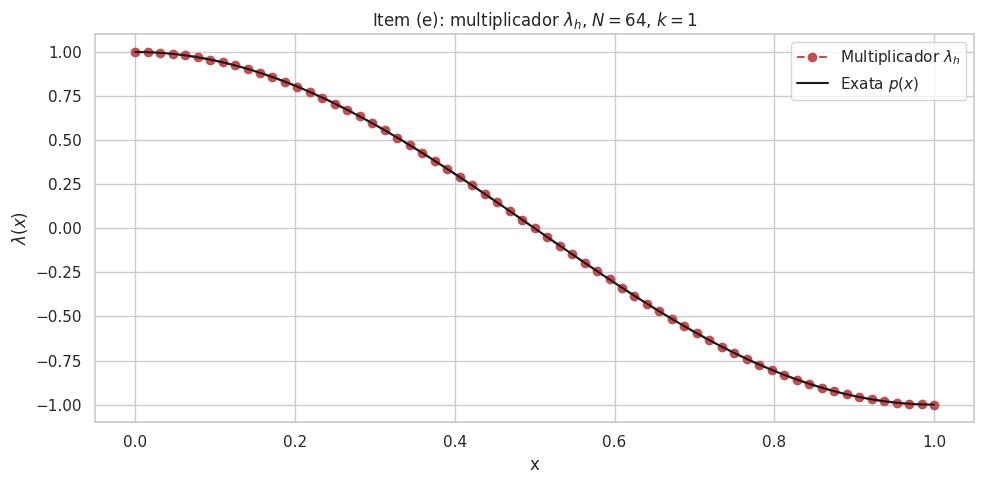

In [49]:
x_exact = np.linspace(0, L, 400)

plt.figure(figsize=(10, 5))

plt.plot(nodes_e, lambda_app_e, 'ro--', label=r'Multiplicador $\lambda_h$')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'Item (e): multiplicador $\lambda_h$, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel(r'$\lambda(x)$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_e_lambda_hibrido.pdf")
plt.show()

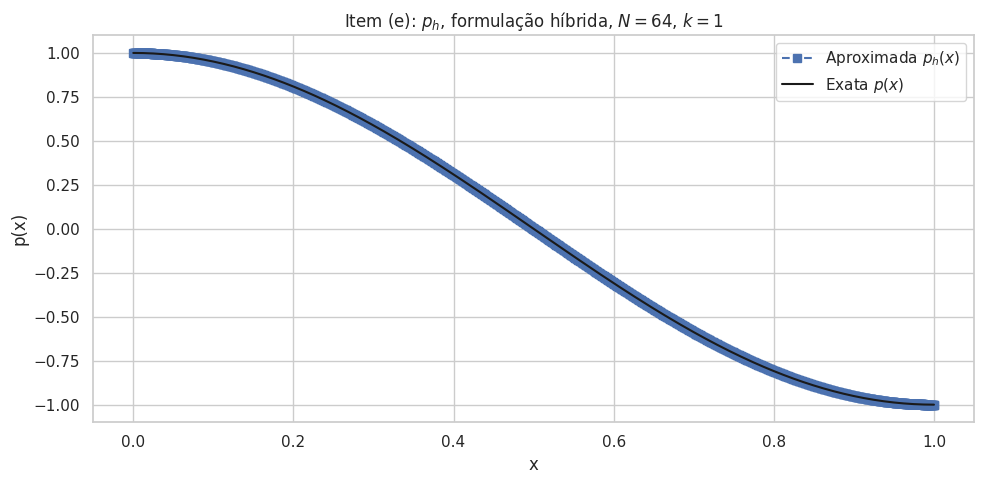

In [51]:
x_disc_e, u_disc_e, p_disc_e = build_discontinuous_plot_data_mixed(
    nodes_e,
    elements_e,
    u_app_e,
    p_app_e,
    k
)

plt.figure(figsize=(10, 5))

plt.plot(x_disc_e, p_disc_e, 'bs--', label=r'Aproximada $p_h(x)$')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'Item (e): $p_h$, formulação híbrida, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_e_p_hibrido.pdf")
plt.show()

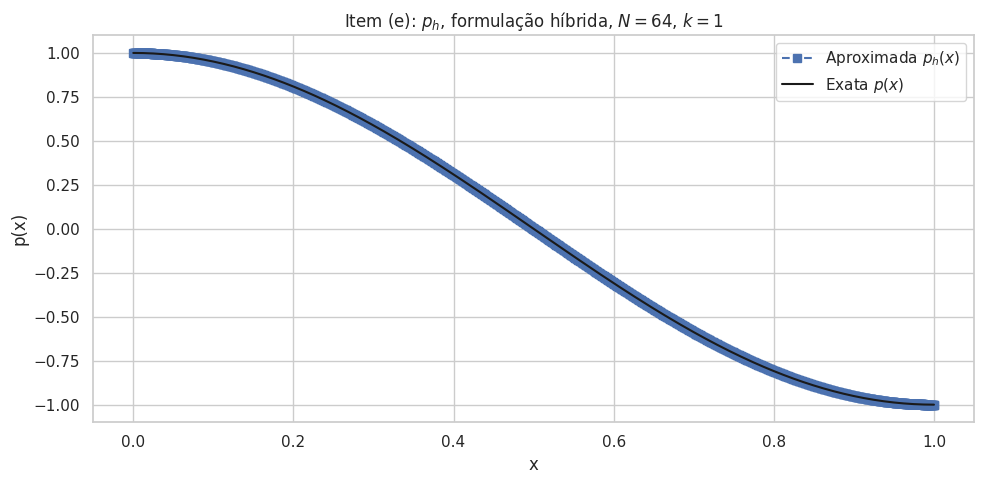

In [53]:
x_disc_e, u_disc_e, p_disc_e = build_discontinuous_plot_data_mixed(
    nodes_e,
    elements_e,
    u_app_e,
    p_app_e,
    k
)

plt.figure(figsize=(10, 5))

plt.plot(x_disc_e, p_disc_e, 'bs--', label=r'Aproximada $p_h(x)$')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'Item (e): $p_h$, formulação híbrida, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_e_p_hibrido.pdf")
plt.show()

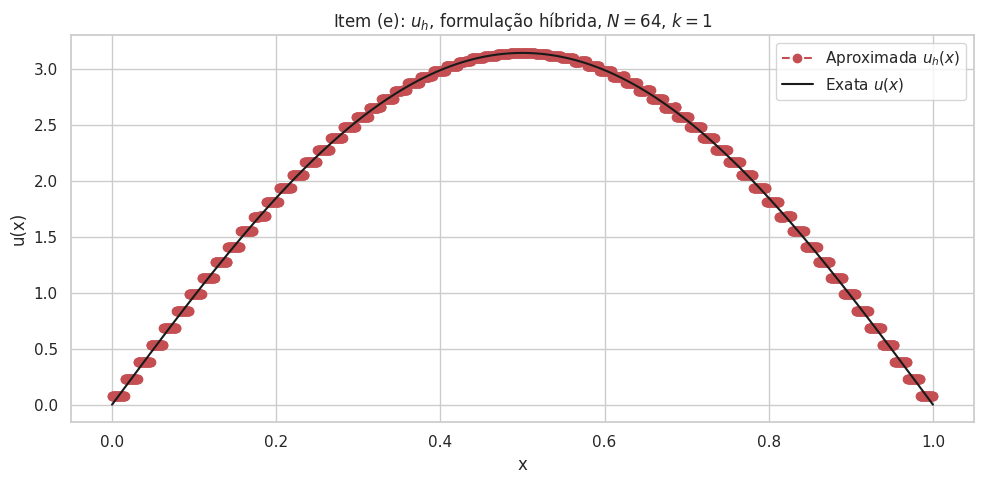

In [54]:
plt.figure(figsize=(10, 5))

plt.plot(x_disc_e, u_disc_e, 'ro--', label=r'Aproximada $u_h(x)$')
plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')

plt.title(rf'Item (e): $u_h$, formulação híbrida, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_e_u_hibrido.pdf")
plt.show()

In [56]:
n_elem_list_hybrid = [16, 32, 64, 128, 256, 512, 1024, 2048]

results_e = convergence_table_dual_hybrid(
    n_elem_list=n_elem_list_hybrid,
    k=1,
    beta0=10.0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h",
    title="TABELA ITEM (e) - FORMULAÇÃO HÍBRIDA COM LAMBDA INCÓGNITO"
)

TABELA ITEM (e) - FORMULAÇÃO HÍBRIDA COM LAMBDA INCÓGNITO
--------------------------------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | beta         | Erro u       | taxa u     | Erro p       | taxa p     | Erro lambda    | taxa lambda  | tempo (s) 
--------------------------------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 1.6000e+02   | 1.2586e-01   | -          | 2.6083e-03   | -          | 4.0184e-15     | -            | 0.0135    
32       | 1   | 3.1250e-02   | 3.2000e+02   | 6.2950e-02   | 1.000      | 6.5240e-04   | 1.999      | 1.0854e-14     | -1.434       | 0.0284    
64       | 1   | 1.5625e-02   | 6.4000e+02   | 3.1478e-02   | 1.000      | 1.6312e-04   | 2.000      | 4.2632e-14     | -1.974       | 0.1388    
128      | 1   | 7.8125e-03   | 1.2800e+03   | 1.5739e-02   | 1.000      | 4

In [57]:
n_elem_list_hybrid = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8000]

results_e = convergence_table_dual_hybrid(
    n_elem_list=n_elem_list_hybrid,
    k=1,
    beta0=10.0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h",
    title="TABELA ITEM (e) - FORMULAÇÃO HÍBRIDA COM LAMBDA INCÓGNITO"
)

TABELA ITEM (e) - FORMULAÇÃO HÍBRIDA COM LAMBDA INCÓGNITO
--------------------------------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | beta         | Erro u       | taxa u     | Erro p       | taxa p     | Erro lambda    | taxa lambda  | tempo (s) 
--------------------------------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 1.6000e+02   | 1.2586e-01   | -          | 2.6083e-03   | -          | 4.0184e-15     | -            | 0.0137    
32       | 1   | 3.1250e-02   | 3.2000e+02   | 6.2950e-02   | 1.000      | 6.5240e-04   | 1.999      | 1.0854e-14     | -1.434       | 0.0272    
64       | 1   | 1.5625e-02   | 6.4000e+02   | 3.1478e-02   | 1.000      | 1.6312e-04   | 2.000      | 4.2632e-14     | -1.974       | 0.0899    
128      | 1   | 7.8125e-03   | 1.2800e+03   | 1.5739e-02   | 1.000      | 4

In [60]:
save_convergence_table_dual_hybrid_txt(
    results_e,
    folder + "tabela_item_e_hibrido_lambda_incognito.txt"
)

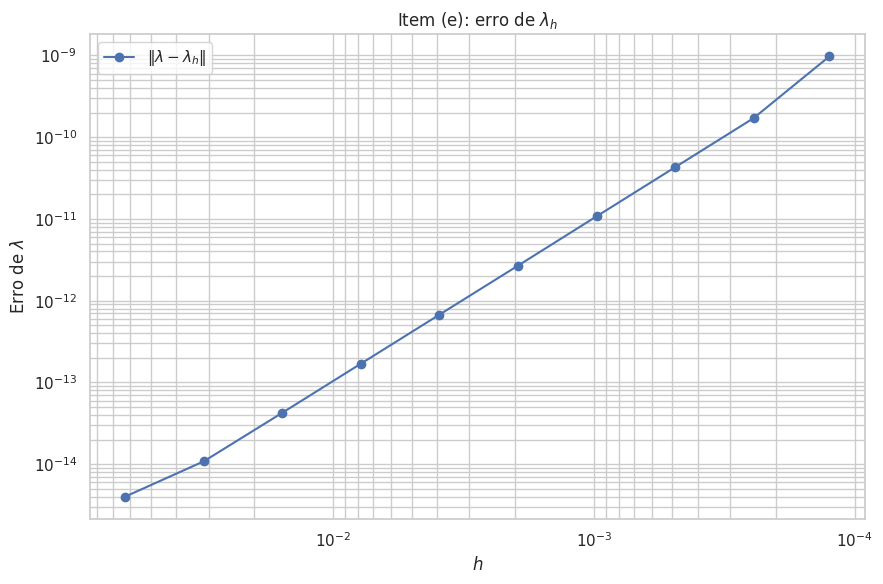

In [62]:
plot_lambda_error_loglog(
    results_e,
    title=r"Item (e): erro de $\lambda_h$",
    x_axis="h",
    save_name="item_e_erro_lambda_loglog_h.pdf"
)

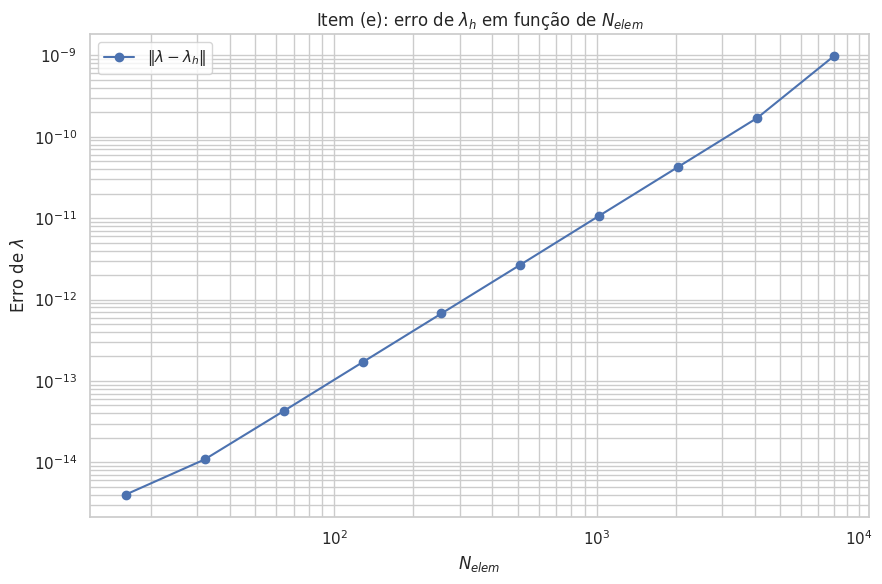

In [63]:
plot_lambda_error_loglog(
    results_e,
    title=r"Item (e): erro de $\lambda_h$ em função de $N_{elem}$",
    x_axis="nelem",
    save_name="item_e_erro_lambda_loglog_nelem.pdf"
)

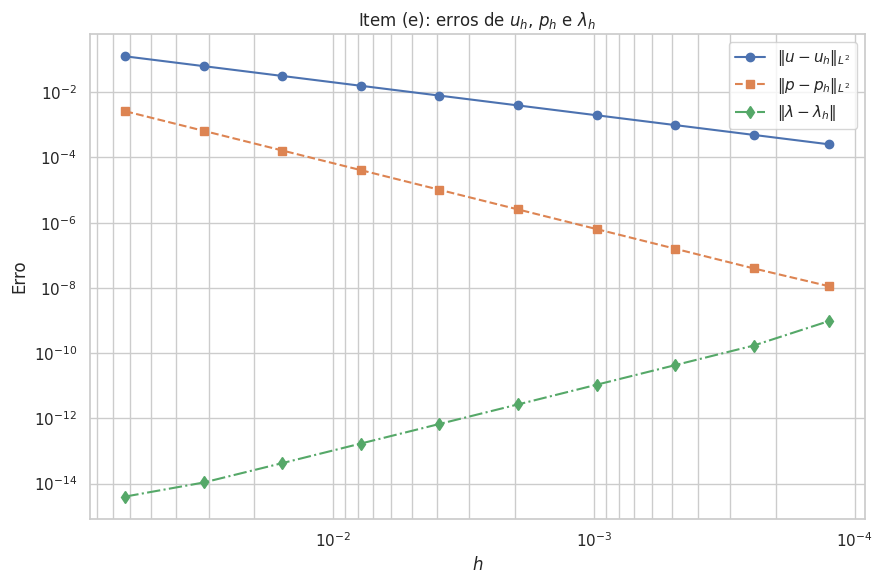

In [66]:
plot_all_errors_dual_hybrid_loglog(
    results_e,
    title=r"Item (e): erros de $u_h$, $p_h$ e $\lambda_h$",
    x_axis="h",
    save_name="item_e_erros_u_p_lambda_loglog_h.pdf"
)

In [67]:
def convergence_study_dual_hybrid_several_k(
    n_elem_list,
    k_list,
    beta0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h",
    l=1.0
):
    all_results = {}

    for k in k_list:
        title = (
            f"TABELA ITEM (f) - HÍBRIDO DUAL, "
            f"k = {k}, beta = beta0*k²/h"
        )

        results_k = convergence_table_dual_hybrid(
            n_elem_list=n_elem_list,
            k=k,
            beta0=beta0,
            delta1=delta1,
            delta2=delta2,
            beta_scale=beta_scale,
            title=title,
            l=l
        )

        all_results[k] = results_k

    return all_results

In [70]:
def save_all_dual_hybrid_tables_single_txt(all_results, filename):
    with open(filename, "w") as file:
        for k, results_k in all_results.items():
            file.write("\n")
            file.write("=" * 160 + "\n")
            file.write(f"ITEM (f) - FORMULAÇÃO HÍBRIDA DUAL - k = {k}\n")
            file.write("=" * 160 + "\n")

            file.write(
                f"{'Nelem':<8} | {'k':<3} | {'h':<12} | {'beta':<12} | "
                f"{'Erro u':<12} | {'taxa u':<10} | "
                f"{'Erro p':<12} | {'taxa p':<10} | "
                f"{'Erro lambda':<14} | {'taxa lambda':<12} | "
                f"{'tempo (s)':<10} | {'cond local max':<15}\n"
            )

            file.write("-" * 160 + "\n")

            for row in results_k:
                if np.isnan(row["rate_u"]):
                    rate_u_str = "-"
                    rate_p_str = "-"
                    rate_lambda_str = "-"
                else:
                    rate_u_str = f"{row['rate_u']:.4f}"
                    rate_p_str = f"{row['rate_p']:.4f}"
                    rate_lambda_str = f"{row['rate_lambda']:.4f}"

                file.write(
                    f"{row['Nelem']:<8} | {row['k']:<3} | "
                    f"{row['h']:<12.4e} | {row['beta']:<12.4e} | "
                    f"{row['err_u']:<12.4e} | {rate_u_str:<10} | "
                    f"{row['err_p']:<12.4e} | {rate_p_str:<10} | "
                    f"{row['err_lambda']:<14.4e} | {rate_lambda_str:<12} | "
                    f"{row['time']:<10.4f} | "
                    f"{row['cond_local_max']:<15.4e}\n"
                )

In [74]:
def plot_errors_several_k(
    all_results,
    variable="u",
    title="Erro L2",
    x_axis="h",
    save_name=None,
    invert_h_axis=True
):
    if variable not in ["u", "p", "lambda"]:
        raise ValueError("variable deve ser 'u', 'p' ou 'lambda'.")

    if x_axis not in ["h", "nelem"]:
        raise ValueError("x_axis deve ser 'h' ou 'nelem'.")

    plt.figure(figsize=(9, 6))

    for k, results_k in all_results.items():
        h = np.array([row["h"] for row in results_k])
        nelem = np.array([row["Nelem"] for row in results_k])

        if variable == "u":
            error = np.array([row["err_u"] for row in results_k])
            ylabel = r"$\|u-u_h\|_{L^2}$"
        elif variable == "p":
            error = np.array([row["err_p"] for row in results_k])
            ylabel = r"$\|p-p_h\|_{L^2}$"
        else:
            error = np.array([row["err_lambda"] for row in results_k])
            ylabel = r"$\|\lambda-\lambda_h\|$"

        if x_axis == "h":
            x = h
            xlabel = r"$h$"
        else:
            x = nelem
            xlabel = r"$N_{elem}$"

        plt.loglog(x, error, "o-", label=rf"$k={k}$")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, which="both")

    if x_axis == "h" and invert_h_axis:
        plt.gca().invert_xaxis()

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(folder + save_name)

    plt.show()

In [69]:
# n_elem_list_f = [16, 32, 64, 128, 256, 512]
k_list_f = [1, 2, 3, 4, 5]

beta0 = 10.0

n_elem_list_f = [16, 32, 64, 128, 256, 512, 1024]

results_f = convergence_study_dual_hybrid_several_k(
    n_elem_list=n_elem_list_f,
    k_list=k_list_f,
    beta0=beta0,
    delta1=0.0,
    delta2=0.0,
    beta_scale="k2_over_h",
    l=1.0
)

TABELA ITEM (f) - HÍBRIDO DUAL, k = 1, beta = beta0*k²/h
--------------------------------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | beta         | Erro u       | taxa u     | Erro p       | taxa p     | Erro lambda    | taxa lambda  | tempo (s) 
--------------------------------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 1.6000e+02   | 1.2586e-01   | -          | 2.6083e-03   | -          | 4.0184e-15     | -            | 0.0137    
32       | 1   | 3.1250e-02   | 3.2000e+02   | 6.2950e-02   | 1.000      | 6.5240e-04   | 1.999      | 1.0854e-14     | -1.434       | 0.0276    
64       | 1   | 1.5625e-02   | 6.4000e+02   | 3.1478e-02   | 1.000      | 1.6312e-04   | 2.000      | 4.2632e-14     | -1.974       | 0.0846    
128      | 1   | 7.8125e-03   | 1.2800e+03   | 1.5739e-02   | 1.000      | 4.

In [72]:
save_all_dual_hybrid_tables_single_txt(
    results_f,
    folder + "tabela_item_f_hibrido_dual_todos_k.txt"
)

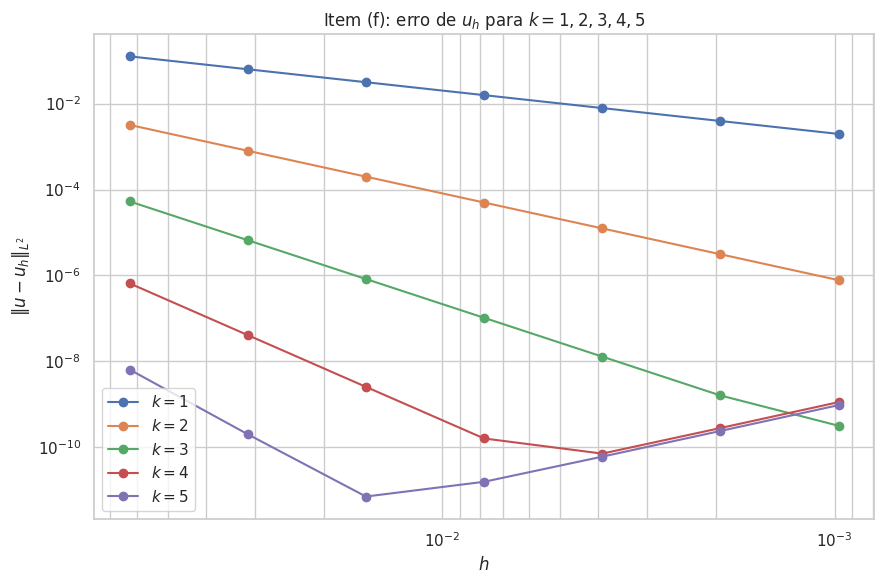

In [75]:
plot_errors_several_k(
    results_f,
    variable="u",
    title=r"Item (f): erro de $u_h$ para $k=1,2,3,4,5$",
    x_axis="h",
    save_name="item_f_erro_u_todos_k.pdf"
)

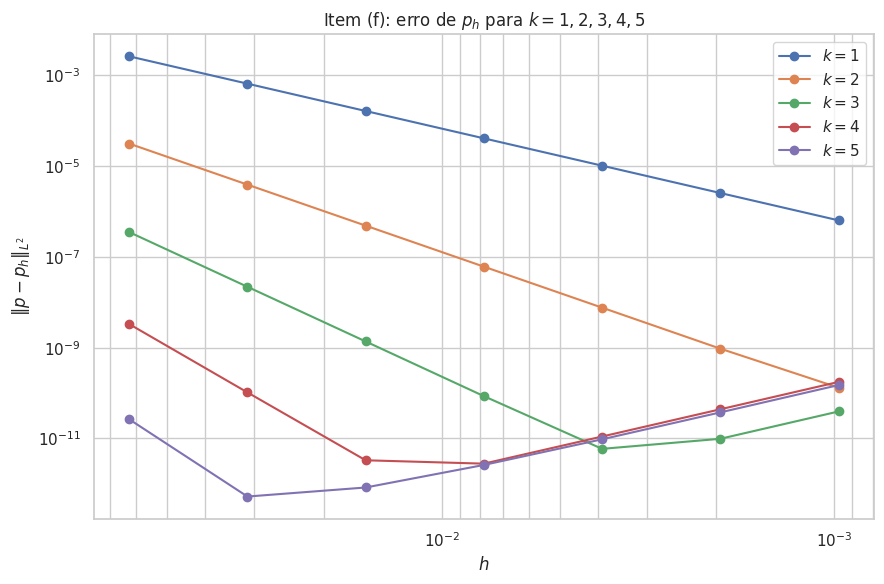

In [76]:
plot_errors_several_k(
    results_f,
    variable="p",
    title=r"Item (f): erro de $p_h$ para $k=1,2,3,4,5$",
    x_axis="h",
    save_name="item_f_erro_p_todos_k.pdf"
)

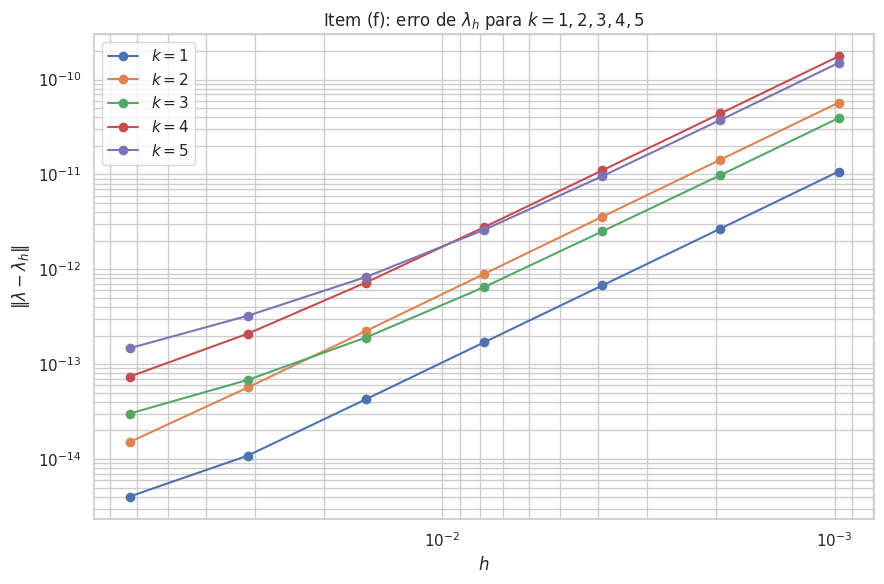

In [77]:
plot_errors_several_k(
    results_f,
    variable="lambda",
    title=r"Item (f): erro de $\lambda_h$ para $k=1,2,3,4,5$",
    x_axis="h",
    save_name="item_f_erro_lambda_todos_k.pdf"
)

In [81]:
def save_all_dual_hybrid_tables_single_txt_general(all_results, filename, title):
    with open(filename, "w") as file:
        for k, results_k in all_results.items():
            file.write("\n")
            file.write("=" * 160 + "\n")
            file.write(f"{title} - k = {k}\n")
            file.write("=" * 160 + "\n")

            file.write(
                f"{'Nelem':<8} | {'k':<3} | {'h':<12} | {'beta':<12} | "
                f"{'Erro u':<12} | {'taxa u':<10} | "
                f"{'Erro p':<12} | {'taxa p':<10} | "
                f"{'Erro lambda':<14} | {'taxa lambda':<12} | "
                f"{'tempo (s)':<10} | {'cond local max':<15}\n"
            )

            file.write("-" * 160 + "\n")

            for row in results_k:
                if np.isnan(row["rate_u"]):
                    rate_u_str = "-"
                    rate_p_str = "-"
                    rate_lambda_str = "-"
                else:
                    rate_u_str = f"{row['rate_u']:.4f}"
                    rate_p_str = f"{row['rate_p']:.4f}"
                    rate_lambda_str = f"{row['rate_lambda']:.4f}"

                file.write(
                    f"{row['Nelem']:<8} | {row['k']:<3} | "
                    f"{row['h']:<12.4e} | {row['beta']:<12.4e} | "
                    f"{row['err_u']:<12.4e} | {rate_u_str:<10} | "
                    f"{row['err_p']:<12.4e} | {rate_p_str:<10} | "
                    f"{row['err_lambda']:<14.4e} | {rate_lambda_str:<12} | "
                    f"{row['time']:<10.4f} | "
                    f"{row['cond_local_max']:<15.4e}\n"
                )

In [78]:
delta1 = -0.5
delta2 = 0.0
beta0 = 0.0

In [79]:
n_elem_list_g = [16, 32, 64, 128, 256, 512, 1024]
k_list_g = [1, 2, 3, 4, 5]

results_g = convergence_study_dual_hybrid_several_k(
    n_elem_list=n_elem_list_g,
    k_list=k_list_g,
    beta0=0.0,
    delta1=-0.5,
    delta2=0.0,
    beta_scale="k2_over_h",
    l=1.0
)

TABELA ITEM (f) - HÍBRIDO DUAL, k = 1, beta = beta0*k²/h
--------------------------------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | beta         | Erro u       | taxa u     | Erro p       | taxa p     | Erro lambda    | taxa lambda  | tempo (s) 
--------------------------------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 0.0000e+00   | 7.8116e-03   | -          | 1.5268e-03   | -          | 1.2532e-15     | -            | 0.0105    
32       | 1   | 3.1250e-02   | 0.0000e+00   | 1.9541e-03   | 1.999      | 3.8116e-04   | 2.002      | 8.2050e-16     | 0.611        | 0.0211    
64       | 1   | 1.5625e-02   | 0.0000e+00   | 4.8861e-04   | 2.000      | 9.5258e-05   | 2.001      | 5.2489e-15     | -2.677       | 0.0683    
128      | 1   | 7.8125e-03   | 0.0000e+00   | 1.2216e-04   | 2.000      | 2.

In [82]:
save_all_dual_hybrid_tables_single_txt_general(
    results_g,
    folder + "tabela_item_g_hibrido_dual_delta1_todos_k.txt",
    title="ITEM (g) - HÍBRIDO DUAL COM DELTA1 = -1/2 E BETA = 0"
)

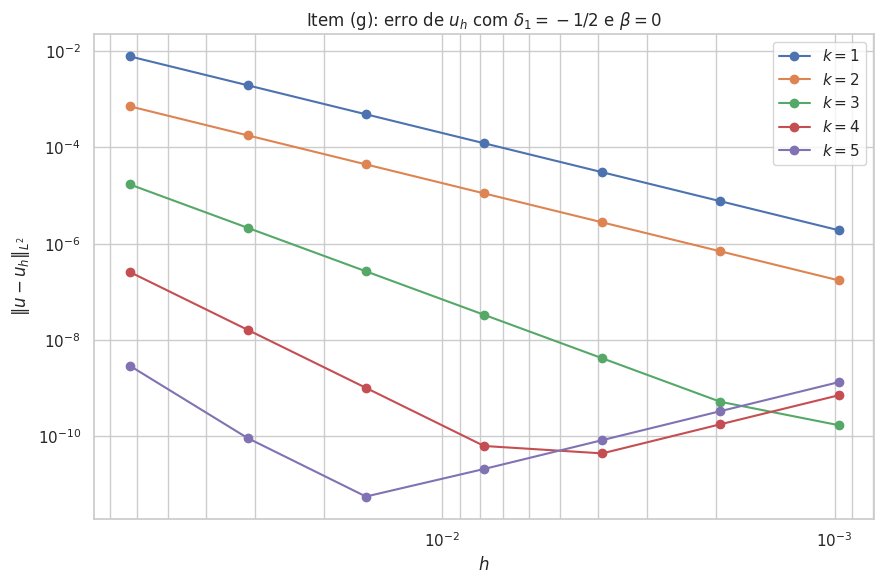

In [83]:
plot_errors_several_k(
    results_g,
    variable="u",
    title=r"Item (g): erro de $u_h$ com $\delta_1=-1/2$ e $\beta=0$",
    x_axis="h",
    save_name="item_g_erro_u_todos_k.pdf"
)

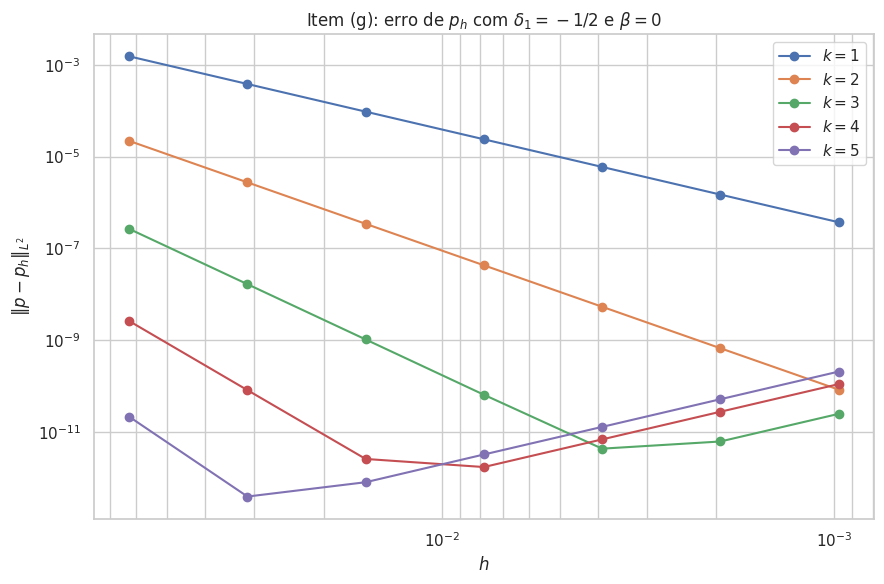

In [84]:
plot_errors_several_k(
    results_g,
    variable="p",
    title=r"Item (g): erro de $p_h$ com $\delta_1=-1/2$ e $\beta=0$",
    x_axis="h",
    save_name="item_g_erro_p_todos_k.pdf"
)

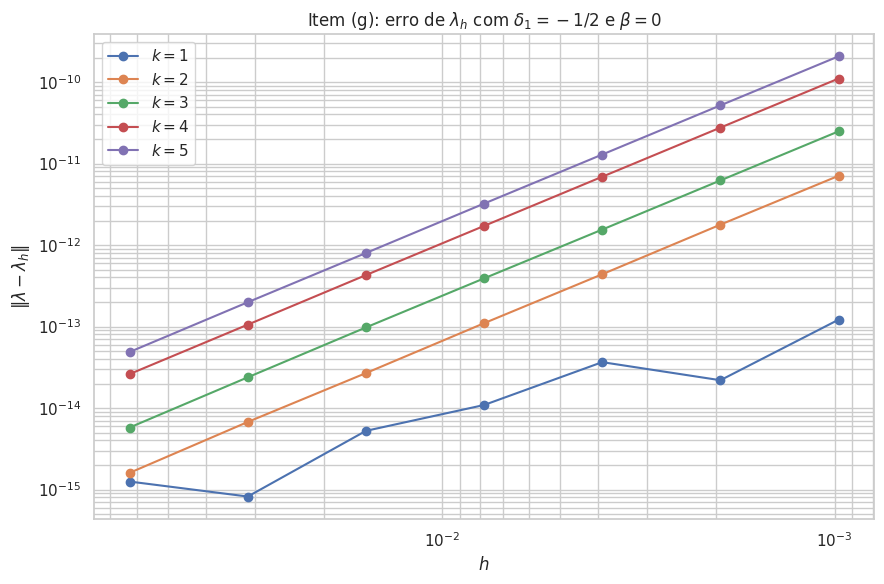

In [85]:
plot_errors_several_k(
    results_g,
    variable="lambda",
    title=r"Item (g): erro de $\lambda_h$ com $\delta_1=-1/2$ e $\beta=0$",
    x_axis="h",
    save_name="item_g_erro_lambda_todos_k.pdf"
)

In [86]:
delta1 = -0.5
delta2 = 0.5
beta0 = 0.0

In [87]:
n_elem_list_h = [16, 32, 64, 128, 256, 512, 1024]
k_list_h = [1, 2, 3, 4, 5]

results_h = convergence_study_dual_hybrid_several_k(
    n_elem_list=n_elem_list_h,
    k_list=k_list_h,
    beta0=0.0,
    delta1=-0.5,
    delta2=0.5,
    beta_scale="k2_over_h",
    l=1.0
)

TABELA ITEM (f) - HÍBRIDO DUAL, k = 1, beta = beta0*k²/h
--------------------------------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | beta         | Erro u       | taxa u     | Erro p       | taxa p     | Erro lambda    | taxa lambda  | tempo (s) 
--------------------------------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 0.0000e+00   | 7.8116e-03   | -          | 1.5268e-03   | -          | 3.4013e-15     | -            | 0.0141    
32       | 1   | 3.1250e-02   | 0.0000e+00   | 1.9541e-03   | 1.999      | 3.8116e-04   | 2.002      | 4.1383e-15     | -0.283       | 0.0255    
64       | 1   | 1.5625e-02   | 0.0000e+00   | 4.8861e-04   | 2.000      | 9.5258e-05   | 2.001      | 6.1911e-14     | -3.903       | 0.0774    
128      | 1   | 7.8125e-03   | 0.0000e+00   | 1.2216e-04   | 2.000      | 2.

In [88]:
save_all_dual_hybrid_tables_single_txt_general(
    results_h,
    folder + "tabela_item_h_hibrido_dual_delta1_delta2_todos_k.txt",
    title="ITEM (h) - HÍBRIDO DUAL COM DELTA1 = -1/2, DELTA2 = 1/2 E BETA = 0"
)

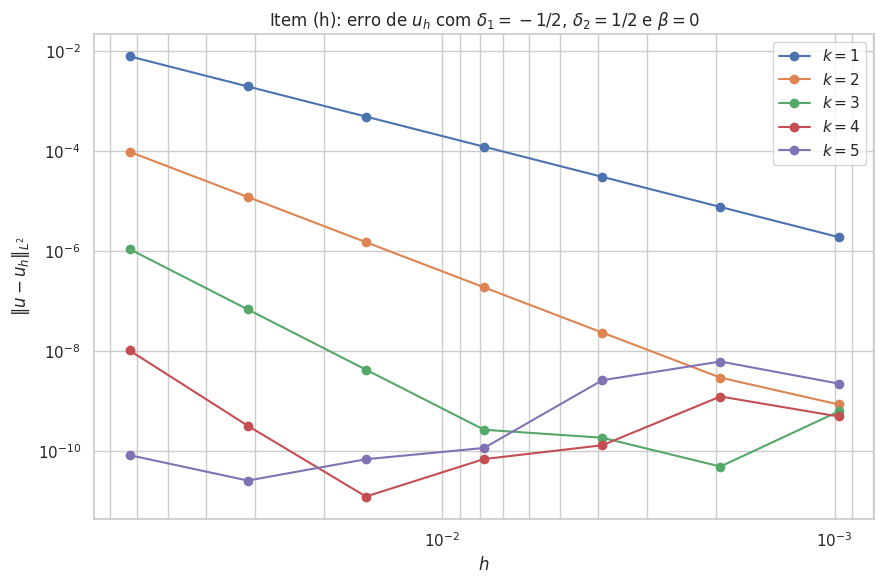

In [89]:
plot_errors_several_k(
    results_h,
    variable="u",
    title=r"Item (h): erro de $u_h$ com $\delta_1=-1/2$, $\delta_2=1/2$ e $\beta=0$",
    x_axis="h",
    save_name="item_h_erro_u_todos_k.pdf"
)

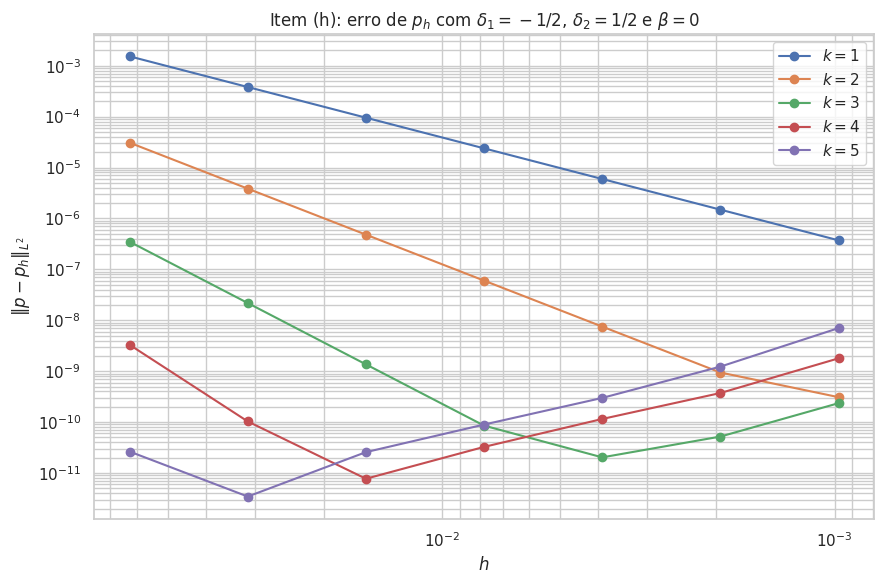

In [90]:
plot_errors_several_k(
    results_h,
    variable="p",
    title=r"Item (h): erro de $p_h$ com $\delta_1=-1/2$, $\delta_2=1/2$ e $\beta=0$",
    x_axis="h",
    save_name="item_h_erro_p_todos_k.pdf"
)

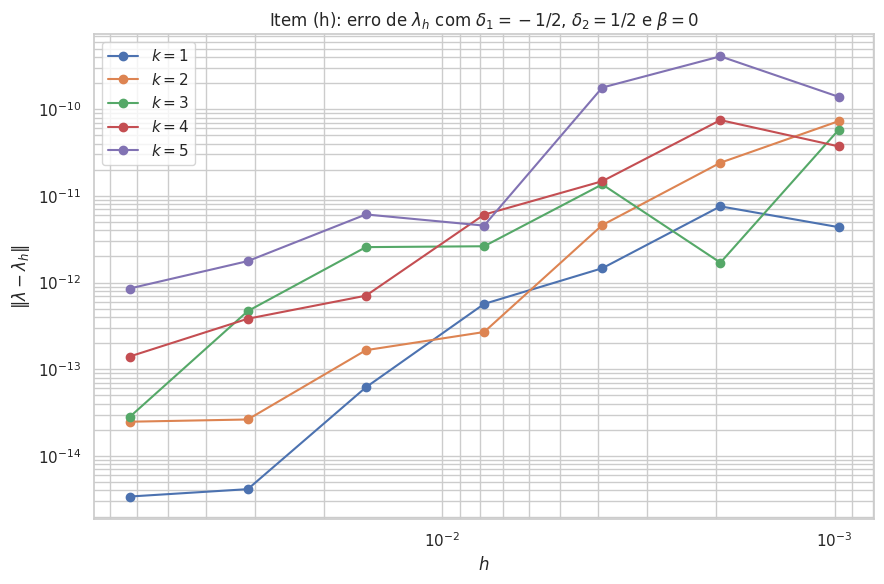

In [91]:
plot_errors_several_k(
    results_h,
    variable="lambda",
    title=r"Item (h): erro de $\lambda_h$ com $\delta_1=-1/2$, $\delta_2=1/2$ e $\beta=0$",
    x_axis="h",
    save_name="item_h_erro_lambda_todos_k.pdf"
)

In [92]:
def plot_compare_items_for_fixed_k(
    results_f,
    results_g,
    results_h,
    k,
    variable="p",
    x_axis="h",
    save_name=None,
    invert_h_axis=True
):
    if variable not in ["u", "p", "lambda"]:
        raise ValueError("variable deve ser 'u', 'p' ou 'lambda'.")

    if x_axis not in ["h", "nelem"]:
        raise ValueError("x_axis deve ser 'h' ou 'nelem'.")

    data_f = results_f[k]
    data_g = results_g[k]
    data_h = results_h[k]

    if x_axis == "h":
        x_f = np.array([row["h"] for row in data_f])
        x_g = np.array([row["h"] for row in data_g])
        x_h = np.array([row["h"] for row in data_h])
        xlabel = r"$h$"
    else:
        x_f = np.array([row["Nelem"] for row in data_f])
        x_g = np.array([row["Nelem"] for row in data_g])
        x_h = np.array([row["Nelem"] for row in data_h])
        xlabel = r"$N_{elem}$"

    if variable == "u":
        err_f = np.array([row["err_u"] for row in data_f])
        err_g = np.array([row["err_u"] for row in data_g])
        err_h = np.array([row["err_u"] for row in data_h])
        ylabel = r"$\|u-u_h\|_{L^2}$"
    elif variable == "p":
        err_f = np.array([row["err_p"] for row in data_f])
        err_g = np.array([row["err_p"] for row in data_g])
        err_h = np.array([row["err_p"] for row in data_h])
        ylabel = r"$\|p-p_h\|_{L^2}$"
    else:
        err_f = np.array([row["err_lambda"] for row in data_f])
        err_g = np.array([row["err_lambda"] for row in data_g])
        err_h = np.array([row["err_lambda"] for row in data_h])
        ylabel = r"$\|\lambda-\lambda_h\|$"

    plt.figure(figsize=(9, 6))

    plt.loglog(x_f, err_f, "o-", label=r"Item (f): $\beta=\beta_0 k^2/h$")
    plt.loglog(x_g, err_g, "s--", label=r"Item (g): $\delta_1=-1/2$")
    plt.loglog(x_h, err_h, "d-.", label=r"Item (h): $\delta_1=-1/2$, $\delta_2=1/2$")

    plt.title(rf"Comparação dos itens (f), (g) e (h), $k={k}$")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, which="both")

    if x_axis == "h" and invert_h_axis:
        plt.gca().invert_xaxis()

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(folder + save_name)

    plt.show()

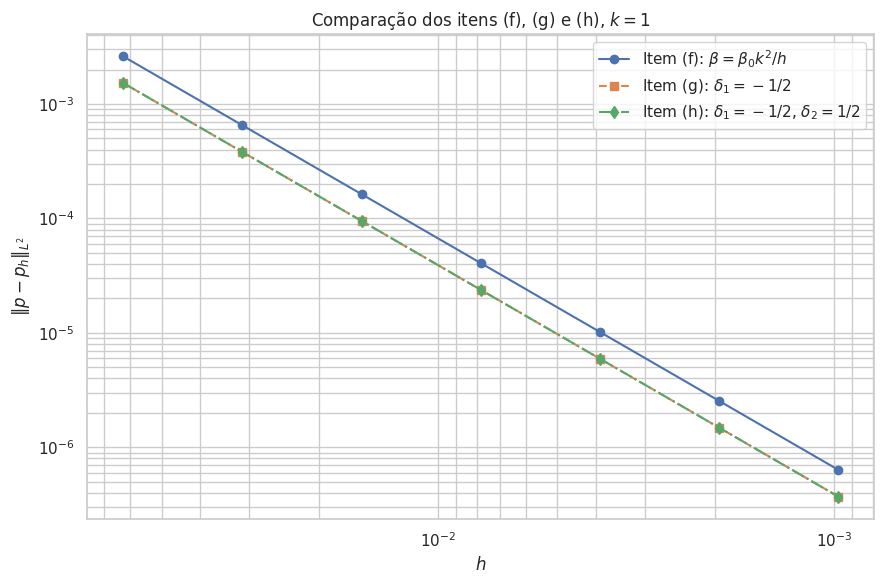

In [93]:
plot_compare_items_for_fixed_k(
    results_f,
    results_g,
    results_h,
    k=1,
    variable="p",
    x_axis="h",
    save_name="comparacao_f_g_h_p_k1.pdf"
)

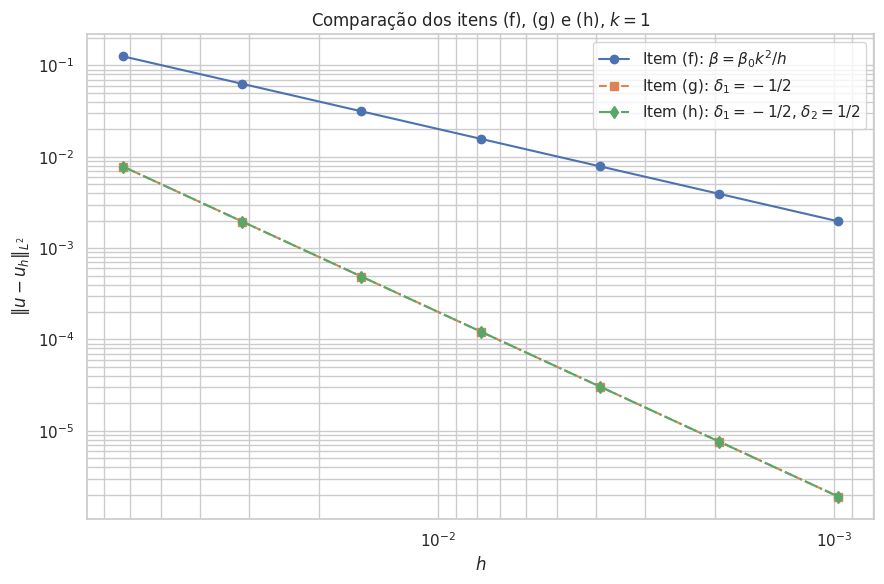

In [94]:
plot_compare_items_for_fixed_k(
    results_f,
    results_g,
    results_h,
    k=1,
    variable="u",
    x_axis="h",
    save_name="comparacao_f_g_h_u_k1.pdf"
)

In [96]:
def solve_poisson_for_lambda(l, n_elem, k):
    n_dofs = n_elem * k + 1
    x_dofs = np.linspace(0.0, l, n_dofs)

    K_global = lil_matrix((n_dofs, n_dofs))
    F_global = np.zeros(n_dofs)

    gauss_pts, weights = leggauss(k + 3)

    for elem_id in range(n_elem):
        x1 = elem_id * l / n_elem
        x2 = (elem_id + 1) * l / n_elem

        h = x2 - x1
        J = h / 2.0

        x_loc = np.linspace(x1, x2, k + 1)
        dofs_loc = [elem_id * k + i for i in range(k + 1)]

        K_loc = np.zeros((k + 1, k + 1))
        F_loc = np.zeros(k + 1)

        for gp, w in zip(gauss_pts, weights):
            N, dN_dxi = lagrange_shape(k, gp)
            dN_dx = dN_dxi / J

            x_gp = np.dot(N, x_loc)
            f_val = exact_f(x_gp)

            for j in range(k + 1):
                F_loc[j] += f_val * N[j] * w * J

                for i in range(k + 1):
                    K_loc[j, i] += dN_dx[i] * dN_dx[j] * w * J

        for j_local, j_global in enumerate(dofs_loc):
            F_global[j_global] += F_loc[j_local]

            for i_local, i_global in enumerate(dofs_loc):
                K_global[j_global, i_global] += K_loc[j_local, i_local]

    # Condições de Dirichlet:
    # p(0) = g(0), p(1) = g(1)

    K_global = K_global.tolil()

    bc_dofs = [0, n_dofs - 1]
    bc_values = [exact_g(0.0), exact_g(l)]

    for dof, value in zip(bc_dofs, bc_values):
        for row in range(n_dofs):
            if row != dof:
                F_global[row] -= K_global[row, dof] * value
                K_global[row, dof] = 0.0

        K_global[dof, :] = 0.0
        K_global[dof, dof] = 1.0
        F_global[dof] = value

    K_global = csr_matrix(K_global)

    p_lambda = spsolve(K_global, F_global)

    return x_dofs, p_lambda

In [97]:
def extract_lambda_values_from_poisson_solution(p_lambda, n_elem, k):
    lambda_values = np.zeros(n_elem + 1)

    for node_id in range(n_elem + 1):
        lambda_values[node_id] = p_lambda[node_id * k]

    return lambda_values

In [98]:
def solve_dual_known_lambda_from_values(
    l,
    n_elem,
    k,
    beta0,
    lambda_values,
    delta1=0.0,
    delta2=0.0,
    beta_scale="constant"
):
    nodes, elements = create_mesh(l, n_elem)

    u_app = np.zeros((n_elem, k + 1))
    p_app = np.zeros((n_elem, k + 1))

    cond_numbers = []

    h = l / n_elem

    if beta_scale == "k2_over_h":
        beta = beta0 * (k ** 2) / h
    elif beta_scale == "one_over_h":
        beta = beta0 / h
    elif beta_scale == "constant":
        beta = beta0
    else:
        raise ValueError("beta_scale deve ser 'k2_over_h', 'one_over_h' ou 'constant'.")

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        A_loc, B_loc, F_loc = local_matrices_dual_known_lambda(
            x1,
            x2,
            k,
            beta,
            delta1,
            delta2
        )

        lambda_loc = np.array([
            lambda_values[n1],
            lambda_values[n2]
        ])

        rhs_loc = F_loc - B_loc @ lambda_loc

        cond_numbers.append(np.linalg.cond(A_loc))

        try:
            U_loc = np.linalg.solve(A_loc, rhs_loc)
        except np.linalg.LinAlgError:
            print(
                f"Matriz local singular no elemento {elem_id}. "
                f"Usando mínimos quadrados."
            )
            U_loc = np.linalg.lstsq(A_loc, rhs_loc, rcond=None)[0]

        u_app[elem_id, :] = U_loc[:k + 1]
        p_app[elem_id, :] = U_loc[k + 1:]

    return nodes, elements, u_app, p_app, cond_numbers, beta

In [99]:
L = 1.0
n_elem = 64
k = 1

x_lambda_i, p_lambda_i = solve_poisson_for_lambda(
    L,
    n_elem,
    k
)

lambda_values_i = extract_lambda_values_from_poisson_solution(
    p_lambda_i,
    n_elem,
    k
)

nodes_i, elements_i, u_app_i, p_app_i, cond_i, beta_i = solve_dual_known_lambda_from_values(
    L,
    n_elem,
    k,
    beta0=0.0,
    lambda_values=lambda_values_i,
    delta1=-0.5,
    delta2=0.5,
    beta_scale="constant"
)

err_u_i = compute_L2_error_discontinuous_variable(
    nodes_i,
    elements_i,
    u_app_i,
    k,
    exact_u
)

err_p_i = compute_L2_error_discontinuous_variable(
    nodes_i,
    elements_i,
    p_app_i,
    k,
    exact_p
)

err_lambda_i = np.linalg.norm(lambda_values_i - exact_lambda(nodes_i)) / np.sqrt(len(nodes_i))

print("RESULTADOS ITEM (i) - LAMBDA APROXIMADO POR POISSON")
print("-" * 105)
print(
    f"{'Nelem':<8} | {'k':<3} | {'h':<10} | {'beta':<12} | "
    f"{'Erro u':<12} | {'Erro p':<12} | {'Erro lambda':<14} | {'cond max':<12}"
)
print("-" * 105)
print(
    f"{n_elem:<8} | {k:<3} | {L/n_elem:<10.4f} | {beta_i:<12.3e} | "
    f"{err_u_i:<12.3e} | {err_p_i:<12.3e} | "
    f"{err_lambda_i:<14.3e} | {max(cond_i):<12.3e}"
)
print("-" * 105)

RESULTADOS ITEM (i) - LAMBDA APROXIMADO POR POISSON
---------------------------------------------------------------------------------------------------------
Nelem    | k   | h          | beta         | Erro u       | Erro p       | Erro lambda    | cond max    
---------------------------------------------------------------------------------------------------------
64       | 1   | 0.0156     | 0.000e+00    | 4.886e-04    | 9.526e-05    | 4.598e-15      | 8.195e+03   
---------------------------------------------------------------------------------------------------------


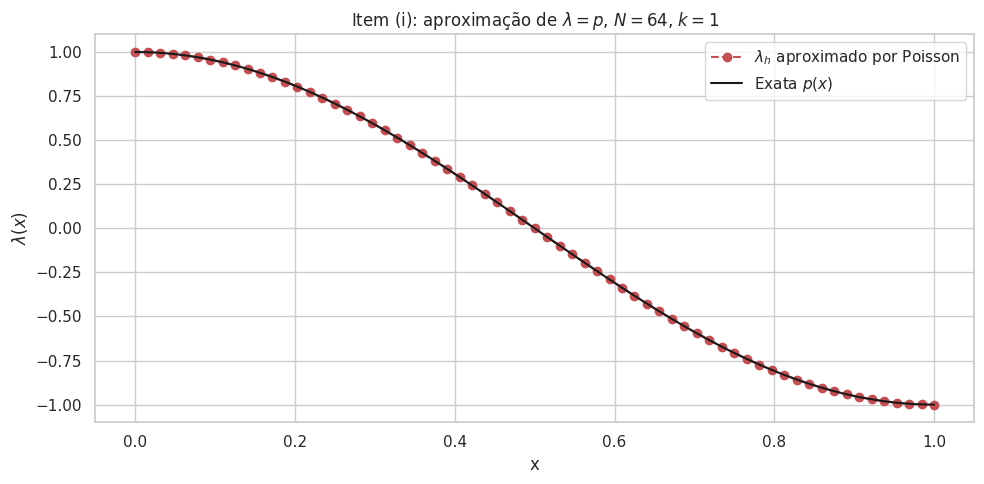

In [101]:
x_exact = np.linspace(0, L, 400)

plt.figure(figsize=(10, 5))

plt.plot(nodes_i, lambda_values_i, 'ro--', label=r'$\lambda_h$ aproximado por Poisson')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'Item (i): aproximação de $\lambda=p$, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel(r'$\lambda(x)$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_i_lambda_aproximado_poisson.pdf")
plt.show()

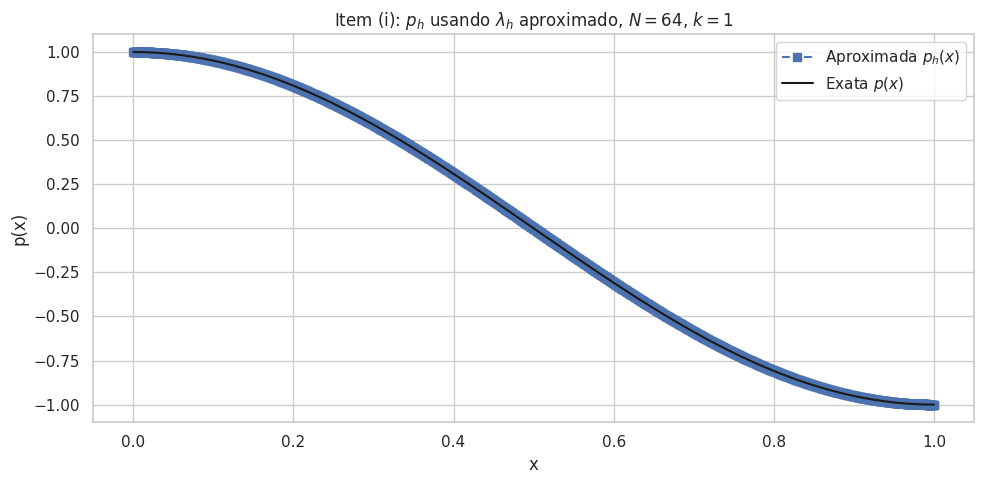

In [103]:
x_disc_i, u_disc_i, p_disc_i = build_discontinuous_plot_data_mixed(
    nodes_i,
    elements_i,
    u_app_i,
    p_app_i,
    k
)

plt.figure(figsize=(10, 5))

plt.plot(x_disc_i, p_disc_i, 'bs--', label=r'Aproximada $p_h(x)$')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'Item (i): $p_h$ usando $\lambda_h$ aproximado, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_i_p_lambda_aproximado.pdf")
plt.show()

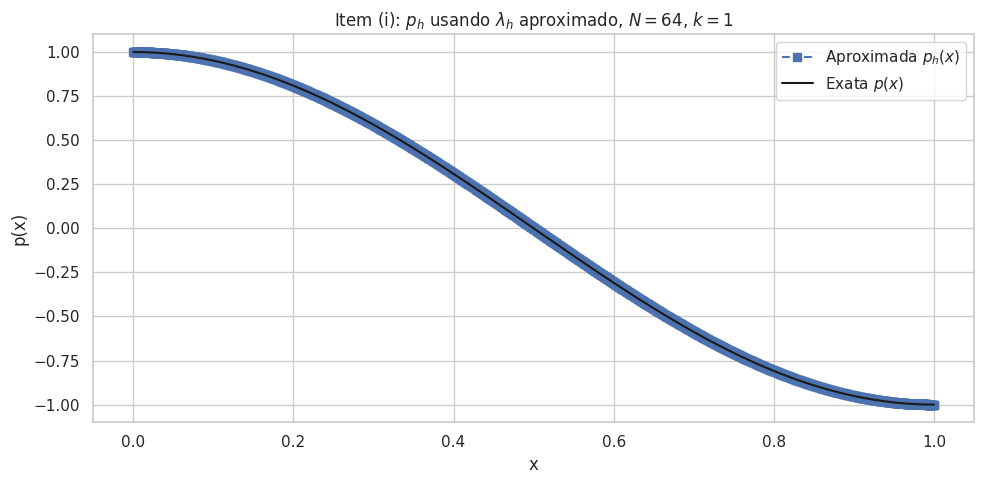

In [105]:
x_disc_i, u_disc_i, p_disc_i = build_discontinuous_plot_data_mixed(
    nodes_i,
    elements_i,
    u_app_i,
    p_app_i,
    k
)

plt.figure(figsize=(10, 5))

plt.plot(x_disc_i, p_disc_i, 'bs--', label=r'Aproximada $p_h(x)$')
plt.plot(x_exact, exact_p(x_exact), 'k-', label=r'Exata $p(x)$')

plt.title(rf'Item (i): $p_h$ usando $\lambda_h$ aproximado, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_i_p_lambda_aproximado.pdf")
plt.show()

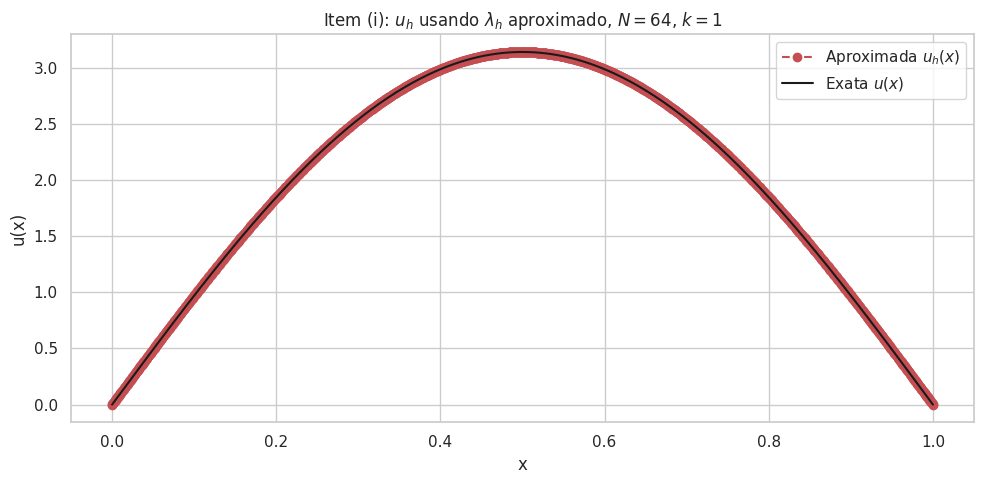

In [106]:
plt.figure(figsize=(10, 5))

plt.plot(x_disc_i, u_disc_i, 'ro--', label=r'Aproximada $u_h(x)$')
plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')

plt.title(rf'Item (i): $u_h$ usando $\lambda_h$ aproximado, $N={n_elem}$, $k={k}$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + "item_i_u_lambda_aproximado.pdf")
plt.show()

In [107]:
def convergence_table_item_i(
    n_elem_list,
    k,
    l=1.0
):
    results = []

    previous_h = None
    previous_err_u = None
    previous_err_p = None
    previous_err_lambda = None

    print(f"TABELA ITEM (i) - LAMBDA APROXIMADO POR POISSON - k = {k}")
    print("-" * 140)
    print(
        f"{'Nelem':<8} | {'k':<3} | {'h':<12} | "
        f"{'Erro u':<12} | {'taxa u':<10} | "
        f"{'Erro p':<12} | {'taxa p':<10} | "
        f"{'Erro lambda':<14} | {'taxa lambda':<12} | "
        f"{'tempo (s)':<10}"
    )
    print("-" * 140)

    for n_elem in n_elem_list:
        start = time.time()

        x_lambda, p_lambda = solve_poisson_for_lambda(
            l,
            n_elem,
            k
        )

        lambda_values = extract_lambda_values_from_poisson_solution(
            p_lambda,
            n_elem,
            k
        )

        nodes, elements, u_app, p_app, cond_numbers, beta = solve_dual_known_lambda_from_values(
            l,
            n_elem,
            k,
            beta0=0.0,
            lambda_values=lambda_values,
            delta1=-0.5,
            delta2=0.5,
            beta_scale="constant"
        )

        err_u = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            u_app,
            k,
            exact_u
        )

        err_p = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            p_app,
            k,
            exact_p
        )

        err_lambda = np.linalg.norm(lambda_values - exact_lambda(nodes)) / np.sqrt(len(nodes))

        elapsed_time = time.time() - start

        h = l / n_elem

        if previous_h is None:
            rate_u = np.nan
            rate_p = np.nan
            rate_lambda = np.nan
        else:
            rate_u = np.log(previous_err_u / err_u) / np.log(previous_h / h)
            rate_p = np.log(previous_err_p / err_p) / np.log(previous_h / h)
            rate_lambda = np.log(previous_err_lambda / err_lambda) / np.log(previous_h / h)

        results.append({
            "Nelem": n_elem,
            "k": k,
            "h": h,
            "beta": beta,
            "err_u": err_u,
            "rate_u": rate_u,
            "err_p": err_p,
            "rate_p": rate_p,
            "err_lambda": err_lambda,
            "rate_lambda": rate_lambda,
            "time": elapsed_time,
            "cond_local_max": max(cond_numbers)
        })

        if np.isnan(rate_u):
            rate_u_str = "-"
            rate_p_str = "-"
            rate_lambda_str = "-"
        else:
            rate_u_str = f"{rate_u:.3f}"
            rate_p_str = f"{rate_p:.3f}"
            rate_lambda_str = f"{rate_lambda:.3f}"

        print(
            f"{n_elem:<8} | {k:<3} | {h:<12.4e} | "
            f"{err_u:<12.4e} | {rate_u_str:<10} | "
            f"{err_p:<12.4e} | {rate_p_str:<10} | "
            f"{err_lambda:<14.4e} | {rate_lambda_str:<12} | "
            f"{elapsed_time:<10.4f}"
        )

        previous_h = h
        previous_err_u = err_u
        previous_err_p = err_p
        previous_err_lambda = err_lambda

    print("-" * 140)

    return results

In [110]:
def convergence_table_item_i(
    n_elem_list,
    k,
    l=1.0
):
    results = []

    previous_h = None
    previous_err_u = None
    previous_err_p = None
    previous_err_lambda = None

    print(f"TABELA ITEM (i) - LAMBDA APROXIMADO POR POISSON - k = {k}")
    print("-" * 140)
    print(
        f"{'Nelem':<8} | {'k':<3} | {'h':<12} | "
        f"{'Erro u':<12} | {'taxa u':<10} | "
        f"{'Erro p':<12} | {'taxa p':<10} | "
        f"{'Erro lambda':<14} | {'taxa lambda':<12} | "
        f"{'tempo (s)':<10}"
    )
    print("-" * 140)

    for n_elem in n_elem_list:
        start = time.time()

        x_lambda, p_lambda = solve_poisson_for_lambda(
            l,
            n_elem,
            k
        )

        lambda_values = extract_lambda_values_from_poisson_solution(
            p_lambda,
            n_elem,
            k
        )

        nodes, elements, u_app, p_app, cond_numbers, beta = solve_dual_known_lambda_from_values(
            l,
            n_elem,
            k,
            beta0=0.0,
            lambda_values=lambda_values,
            delta1=-0.5,
            delta2=0.5,
            beta_scale="constant"
        )

        err_u = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            u_app,
            k,
            exact_u
        )

        err_p = compute_L2_error_discontinuous_variable(
            nodes,
            elements,
            p_app,
            k,
            exact_p
        )

        err_lambda = np.linalg.norm(lambda_values - exact_lambda(nodes)) / np.sqrt(len(nodes))

        elapsed_time = time.time() - start

        h = l / n_elem

        if previous_h is None:
            rate_u = np.nan
            rate_p = np.nan
            rate_lambda = np.nan
        else:
            rate_u = np.log(previous_err_u / err_u) / np.log(previous_h / h)
            rate_p = np.log(previous_err_p / err_p) / np.log(previous_h / h)
            rate_lambda = np.log(previous_err_lambda / err_lambda) / np.log(previous_h / h)

        results.append({
            "Nelem": n_elem,
            "k": k,
            "h": h,
            "beta": beta,
            "err_u": err_u,
            "rate_u": rate_u,
            "err_p": err_p,
            "rate_p": rate_p,
            "err_lambda": err_lambda,
            "rate_lambda": rate_lambda,
            "time": elapsed_time,
            "cond_local_max": max(cond_numbers)
        })

        if np.isnan(rate_u):
            rate_u_str = "-"
            rate_p_str = "-"
            rate_lambda_str = "-"
        else:
            rate_u_str = f"{rate_u:.3f}"
            rate_p_str = f"{rate_p:.3f}"
            rate_lambda_str = f"{rate_lambda:.3f}"

        print(
            f"{n_elem:<8} | {k:<3} | {h:<12.4e} | "
            f"{err_u:<12.4e} | {rate_u_str:<10} | "
            f"{err_p:<12.4e} | {rate_p_str:<10} | "
            f"{err_lambda:<14.4e} | {rate_lambda_str:<12} | "
            f"{elapsed_time:<10.4f}"
        )

        previous_h = h
        previous_err_u = err_u
        previous_err_p = err_p
        previous_err_lambda = err_lambda

    print("-" * 140)

    return results

In [112]:
def convergence_study_item_i_several_k(
    n_elem_list,
    k_list,
    l=1.0
):
    all_results = {}

    for k in k_list:
        results_k = convergence_table_item_i(
            n_elem_list=n_elem_list,
            k=k,
            l=l
        )

        all_results[k] = results_k

    return all_results

In [113]:
n_elem_list_i = [16, 32, 64, 128, 256, 512, 1024]
k_list_i = [1, 2, 3, 4, 5]

results_i = convergence_study_item_i_several_k(
    n_elem_list=n_elem_list_i,
    k_list=k_list_i,
    l=1.0
)

TABELA ITEM (i) - LAMBDA APROXIMADO POR POISSON - k = 1
--------------------------------------------------------------------------------------------------------------------------------------------
Nelem    | k   | h            | Erro u       | taxa u     | Erro p       | taxa p     | Erro lambda    | taxa lambda  | tempo (s) 
--------------------------------------------------------------------------------------------------------------------------------------------
16       | 1   | 6.2500e-02   | 7.8116e-03   | -          | 1.5268e-03   | -          | 1.2428e-15     | -            | 0.0169    
32       | 1   | 3.1250e-02   | 1.9541e-03   | 1.999      | 3.8116e-04   | 2.002      | 6.0516e-16     | 1.038        | 0.0296    
64       | 1   | 1.5625e-02   | 4.8861e-04   | 2.000      | 9.5258e-05   | 2.001      | 4.5977e-15     | -2.926       | 0.0573    
128      | 1   | 7.8125e-03   | 1.2216e-04   | 2.000      | 2.3812e-05   | 2.000      | 9.2802e-15     | -1.013       | 0.1139    
256    

In [114]:
save_all_dual_hybrid_tables_single_txt_general(
    results_i,
    folder + "tabela_item_i_lambda_poisson_todos_k.txt",
    title="ITEM (i) - LAMBDA APROXIMADO POR POISSON E RECUPERACAO COM DELTA1 = -1/2, DELTA2 = 1/2"
)

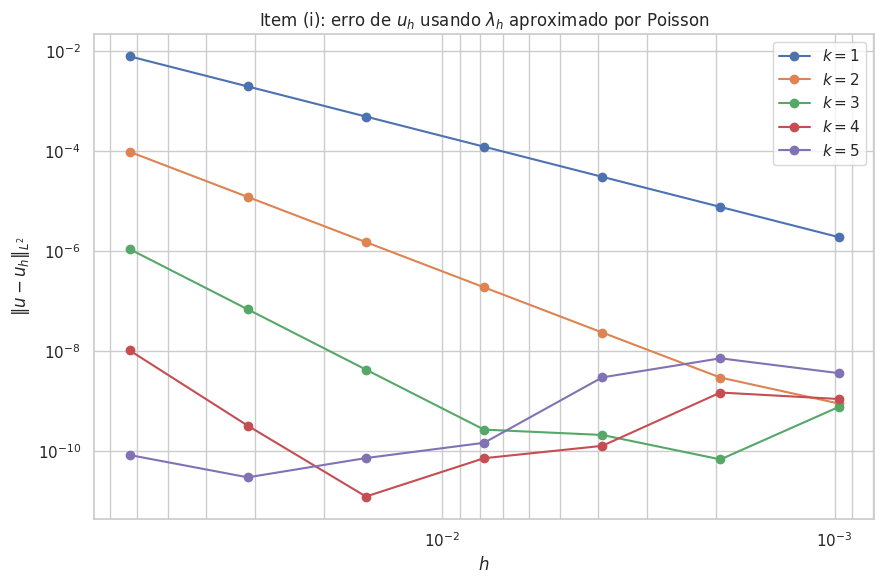

In [115]:
plot_errors_several_k(
    results_i,
    variable="u",
    title=r"Item (i): erro de $u_h$ usando $\lambda_h$ aproximado por Poisson",
    x_axis="h",
    save_name="item_i_erro_u_todos_k.pdf"
)

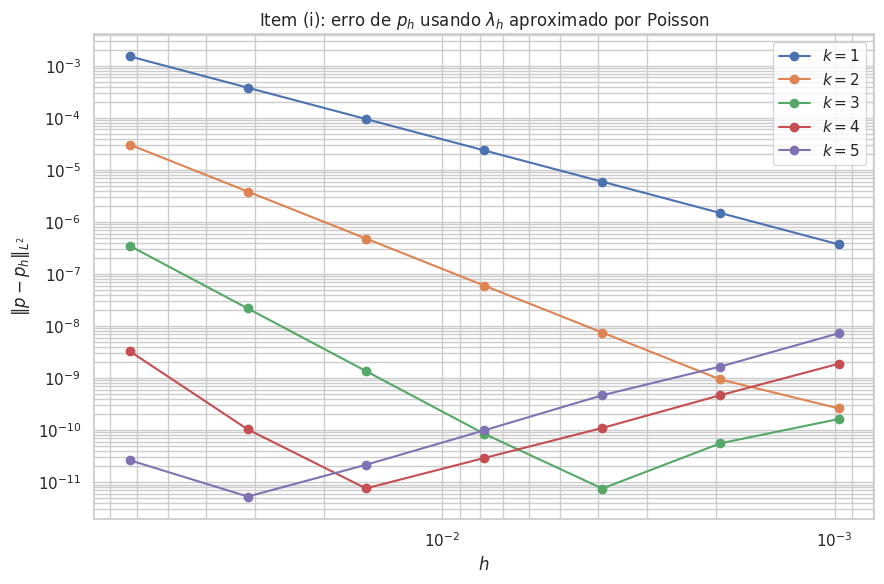

In [116]:
plot_errors_several_k(
    results_i,
    variable="p",
    title=r"Item (i): erro de $p_h$ usando $\lambda_h$ aproximado por Poisson",
    x_axis="h",
    save_name="item_i_erro_p_todos_k.pdf"
)

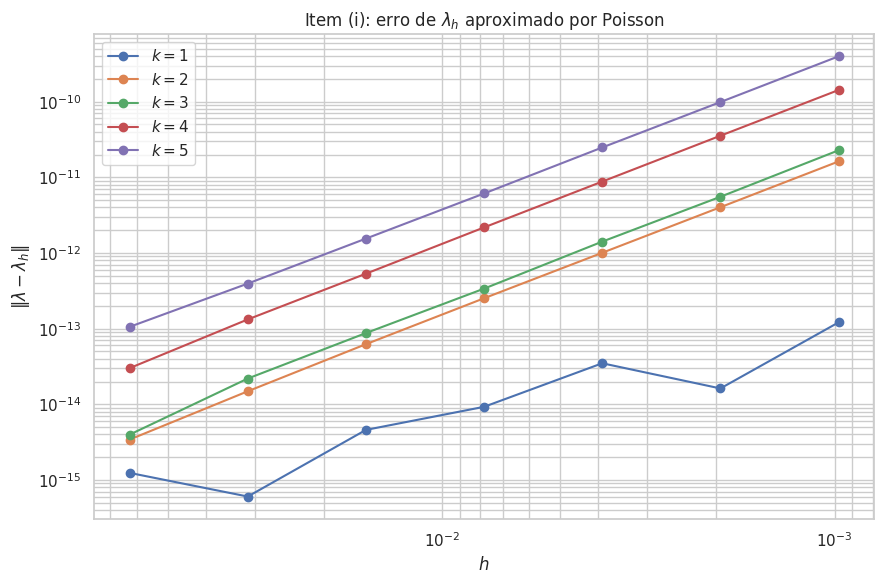

In [117]:
plot_errors_several_k(
    results_i,
    variable="lambda",
    title=r"Item (i): erro de $\lambda_h$ aproximado por Poisson",
    x_axis="h",
    save_name="item_i_erro_lambda_todos_k.pdf"
)